# 💼 Motor de Business Impact & Financial Valuation

**Objetivo:** Traduzir a performance estatística do **Modelo Behavior Score** em valor financeiro real, medindo o impacto no EBITDA da Claro através da alavancagem de Upsell e da forte mitigação de inadimplência (PDD).

---

## 🔬 1. Metodologia de Validação: O Grupo Controle "Sem Política"
Para garantir rigor científico absoluto, toda a simulação financeira e a análise de Swap são executadas **exclusivamente sobre o Grupo Controle** (CPFs terminados em ZZ e ZX). 

**Qual a vantagem estratégica de usar este grupo?**
Conforme diretriz do projeto, este grupo Controle representa clientes que **foram aprovados direto, sem passar pela política de corte do Bureau**. Isso nos dá um laboratório perfeito, livre de viés de seleção:
* **A Base Bruta (Sem Política):** Nos revela a inadimplência natural (FPD) da população quando nenhuma regra de crédito é aplicada.
* **Simulação do Legado (Bureau):** Ao aplicarmos a nota do Bureau sobre este grupo, podemos medir exatamente qual seria a performance e o caixa da política legada.
* **Simulação do Novo Motor (Behavior):** Aplicamos nosso modelo sobre a mesma base. A diferença de rentabilidade entre as duas simulações (Swap-In e Swap-Out) comprova matematicamente a superioridade da **modelagem comportamental avançada** sobre as regras tradicionais de mercado.

---

## ⚙️ 2. Como Calculamos o Motor Financeiro? (Premissas e Fórmulas)
Para não basear nosso Business Case em "achismos", fomos diretamente à camada Bronze do Data Lake para extrair o comportamento real dos clientes e calibrar nosso motor:

* 📈 **ARPU Alvo (Controle):** O ticket médio que o cliente passa a pagar ao migrar. Calculado pela média de `val_pagamento_fatura` (removendo outliers) na base de Pagamentos.
* 📉 **ARPU Base (Pré-Pago):** O valor que o cliente já gastava antes de migrar. Calculado pela soma mensal de `val_credito_inserido` na plataforma `PREPG`.
* 💰 **Receita Incremental (Upsell):** `ARPU Controle - ARPU Pré-Pago`. Este é o dinheiro *novo* que entra no caixa da Claro quando acertamos uma migração (Swap-In de qualidade).
* 🎯 **Taxa de Conversão Orgânica:** Calculada cruzando a base de Controle com os Dados Cadastrais para ver, na prática, qual o percentual exato de CPFs que efetivaram a migração de plano na nossa amostra.
* 🚀 **Taxa de Conversão Nacional:** Diferente da orgânica, este é o *Target* de Negócios (ex: 3%). Usada para simular o impacto de campanhas de marketing na escala nacional.
* ⏳ **Horizonte de LTV (Lifetime Value):** Definido como 12 meses. É a janela de tempo que usamos para projetar o lucro acumulado (Upsell) que um bom cliente traz para a companhia no ano.
* 🛑 **Horizonte de Perda (Loss/PDD):** Definido como 3 meses. Representa o impacto financeiro gerado por um mau pagador aprovado erroneamente. É a provisão de devedores duvidosos que o modelo economiza ao realizar um bloqueio assertivo (Swap-Out).

---

## 🌎 3. A Lógica de Extrapolação Nacional
Nosso laboratório ocorre em uma amostra isolada de cerca de 110 mil clientes (Controle). Para projetar o **EBITDA Incremental** na carteira real da Claro, utilizamos um Fator de Escala simples: `(Base Total / Volume da Amostra) * Taxa de Conversão`. 

**O Tamanho da Oportunidade (Fonte: Anatel):** Para a projeção nacional, adotamos a premissa de uma base elegível de **35 milhões de clientes**. Este volume está rigorosamente alinhado com os dados oficiais da **Anatel / Teleco**, que apontam o *Market Share* histórico recente de linhas ativas na base Pré-Paga da Claro no Brasil gravitando exatamente nesta faixa (entre 31 e 35 milhões de acessos).

Dessa forma, demonstramos que a adoção do motor não traz apenas ganhos na métrica de KS, mas funciona como um **escudo de caixa e um alavancador de margem anticíclico** em nível nacional, com potencial para impactar a maior base de clientes da América Latina.

In [1]:
# ---------------------------------------------------------
# IMPORTAÇÃO DE PACOTES E CONFIGURAÇÕES VISUAIS
# ---------------------------------------------------------
import os
import warnings
import textwrap
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import duckdb
import pyarrow as pa

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import plotly.io as pio

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

COR_FUNDO = '#e4e3e3'
plt.rcParams['figure.facecolor'] = COR_FUNDO
plt.rcParams['axes.facecolor'] = COR_FUNDO
plt.rcParams['font.family'] = 'sans-serif'

# Template customizado para o Plotly usar o fundo correto e tons pastéis
meu_template = go.layout.Template(
    layout=dict(
        paper_bgcolor=COR_FUNDO,
        plot_bgcolor=COR_FUNDO,
        font=dict(color='#333333')
    )
)
pio.templates.default = meu_template

In [2]:
# ---------------------------------------------------------
# CONEXÃO DATA LAKE (BRONZE) E ENRIQUECIMENTO
# ---------------------------------------------------------

def get_duckdb_connection(memory_limit: str = "6GB", threads: int = 4) -> duckdb.DuckDBPyConnection:
    """Estabelece conexão com o S3 via DuckDB otimizada para uso de memória."""
    endpoint = os.getenv("S3_ENDPOINT", "")
    parsed = urlparse(endpoint)
    
    con = duckdb.connect()
    con.execute(f"""
        INSTALL httpfs; LOAD httpfs;
        SET memory_limit='{memory_limit}'; SET threads={threads};
        SET s3_endpoint='{parsed.netloc}';
        SET s3_access_key_id='{os.getenv("AWS_ACCESS_KEY_ID")}';
        SET s3_secret_access_key='{os.getenv("AWS_SECRET_ACCESS_KEY")}';
        SET s3_region='{os.getenv("AWS_DEFAULT_REGION", "us-east-1")}';
        SET s3_use_ssl=false; SET s3_url_style='path';
    """)
    return con

con = get_duckdb_connection()

In [3]:
# ---------------------------------------------------------
# MAPEAMENTO DINÂMICO E CARGA DE DADOS
# ---------------------------------------------------------

ROOT_DIR = Path.cwd().parent.parent 

ARTIFACTS_DIR = ROOT_DIR / 'reports' / 'observability' / 'modeling' / 'v1' / 'artifacts'
ARQUIVO_PARQUET = ARTIFACTS_DIR / 'base_escorada_swap_v1.parquet'

FIGURES_DIR = ROOT_DIR / 'reports' / 'observability' / 'business_impact' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True) 

print("=" * 60)
print("⚙️ SETUP DE AMBIENTE CONCLUÍDO")
print("=" * 60)
print(f"📂 Diretório Raiz do Projeto: {ROOT_DIR.name}/")
print(f"📥 Lendo artefatos de: {ARTIFACTS_DIR.relative_to(ROOT_DIR)}")
print(f"📤 Salvando imagens em: {FIGURES_DIR.relative_to(ROOT_DIR)}")

# --- CARREGANDO A BASE ESCORADA ---
print("\n⏳ Carregando a base escorada (Holdout)...")
try:
    df_swap = pd.read_parquet(ARQUIVO_PARQUET)
    print(f"✅ Base carregada com sucesso! Total de registros: {len(df_swap):,.0f}".replace(',', '.'))
    display(df_swap.head())
    
except FileNotFoundError:
    print(f"\n❌ ERRO: Arquivo não encontrado em:\n{ARQUIVO_PARQUET}")
    print("Verifique se o notebook anterior foi executado e salvou o .parquet corretamente.")

⚙️ SETUP DE AMBIENTE CONCLUÍDO
📂 Diretório Raiz do Projeto: hackathon-pod-squad3-core/
📥 Lendo artefatos de: reports/observability/modeling/v1/artifacts
📤 Salvando imagens em: reports/observability/business_impact/figures

⏳ Carregando a base escorada (Holdout)...
✅ Base carregada com sucesso! Total de registros: 110.268


,num_cpf,target,bur_score_02,prob_modelo,aprova_bureau,aprova_modelo,categoria
0,YYWXNZZX7ZZ,1,404.0,0.535013,0,0,4. Ambos Rejeitam
1,YYWZNZXU7UU,0,696.0,0.060916,1,1,1. Ambos Aprovam
2,YYWZXZZN88W,0,691.0,0.212687,1,1,1. Ambos Aprovam
3,YYX87ZXU7YZ,1,672.0,0.197783,1,1,1. Ambos Aprovam
4,YYX9WZZT877,0,636.0,0.229525,1,1,1. Ambos Aprovam


In [4]:
# ---------------------------------------------------------
# EXTRAÇÃO E DEFINIÇÃO DE PREMISSAS DE NEGÓCIO
# ---------------------------------------------------------

print("🔍 Analisando histórico na camada Bronze para calibração do Motor de Decisão...\n")

# Inicialização de variáveis com valores default (fallback)
ARPU_CONTROLE, ARPU_PRE, TAXA_CONVERSAO_AMOSTRA = 61.18, 20.00, 0.025
origem_controle = origem_pre = origem_conv = "S3 (Caminho Padrão)"

try:
    con.register('df_swap_tabela', df_swap)
    
    # 1. ARPU Controle
    query_arpu_controle = """
        SELECT AVG(val_pagamento_fatura)
        FROM read_parquet('s3://lake/bronze/pagamento/**/*.parquet')
        WHERE val_pagamento_fatura > 5  
          AND val_pagamento_fatura < 300 
    """
    arpu_controle_real = con.execute(query_arpu_controle).fetchone()[0]
    if arpu_controle_real:
        ARPU_CONTROLE = float(arpu_controle_real)
        origem_controle = "S3 Dinâmico (lake/bronze/pagamento)"

    # 2. ARPU Pré-Pago
    query_arpu_pre = """
        SELECT AVG(recarga_mensal)
        FROM (
            SELECT num_cpf, ano_mes, SUM(val_credito_inserido) as recarga_mensal
            FROM read_parquet('s3://lake/bronze/recarga/**/*.parquet')
            WHERE cod_plataforma_atu = 'PREPG'
            GROUP BY num_cpf, ano_mes
        )
        WHERE recarga_mensal > 0
    """
    arpu_pre_real = con.execute(query_arpu_pre).fetchone()[0]
    if arpu_pre_real:
        ARPU_PRE = float(arpu_pre_real)
        origem_pre = "S3 Dinâmico (lake/bronze/recarga)"

    # 3. Taxa de Conversão Orgânica
    query_conversao = """
        WITH controle_cpfs AS (
            SELECT DISTINCT num_cpf FROM df_swap_tabela WHERE SUBSTRING(num_cpf, 6, 2) IN ('ZZ', 'ZX')
        ),
        referencia_s3 AS (
            SELECT s.num_cpf, MIN(dc.safra) as safra_referencia
            FROM controle_cpfs s
            INNER JOIN read_parquet('s3://lake/bronze/dados_cadastrais/**/*.parquet') dc ON s.num_cpf = dc.num_cpf
            GROUP BY 1
        ),
        conversoes AS (
            SELECT DISTINCT r.num_cpf
            FROM referencia_s3 r
            INNER JOIN read_parquet('s3://lake/bronze/dados_cadastrais/**/*.parquet') dc ON r.num_cpf = dc.num_cpf
            WHERE dc.safra > r.safra_referencia 
              AND dc.flag_mig2 NOT IN ('PRE', 'NULL')
        )
        SELECT COUNT(DISTINCT c.num_cpf) * 1.0 / NULLIF(COUNT(DISTINCT r.num_cpf), 0) 
        FROM referencia_s3 r 
        LEFT JOIN conversoes c ON r.num_cpf = c.num_cpf
    """
    taxa_real_raw = con.execute(query_conversao).fetchone()[0]
    if taxa_real_raw:
        TAXA_CONVERSAO_AMOSTRA = float(taxa_real_raw)
        origem_conv = "S3 Dinâmico (lake/bronze/dados_cadastrais)"

except Exception as e:
    print(f"⚠️ Conexão S3 inativa ou limitada. Consumindo Profile Validado. Erro: {e}\n")

# Variáveis Derivadas e Regras Fixas de Negócio
UPSELL = ARPU_CONTROLE - ARPU_PRE
TAXA_CONVERSAO_META = 0.03  
MESES_LTV = 12             
MESES_INADIMPLENCIA = 3           
BASE_TOTAL_CLARO = 35_000_000 # Variável global adicionada para facilitar cálculos futuros

df_premissas = pd.DataFrame([
    {"Parâmetro": "ARPU Alvo (Controle)", "Valor": f"R$ {ARPU_CONTROLE:.2f}", "Lógica / Cálculo": "AVG(pagamento_fatura) | Filtro: R$ 5 < val < R$ 300", "Origem": origem_controle, "Impacto": "Receita Projetada (+)"},
    {"Parâmetro": "ARPU Base (Pré-Pago)", "Valor": f"R$ {ARPU_PRE:.2f}", "Lógica / Cálculo": "AVG(SUM(recarga) por CPF/Mês) | Filtro: PREPG", "Origem": origem_pre, "Impacto": "Custo de Oportunidade (-)"},
    {"Parâmetro": "Receita Incremental (Upsell)", "Valor": f"R$ {UPSELL:.2f}", "Lógica / Cálculo": "Subtração direta: ARPU Alvo - ARPU Base", "Origem": "Calculado (Interno)", "Impacto": "Motor de Swap-In (+)"},
    {"Parâmetro": "Conversão Orgânica (Amostra)", "Valor": f"{TAXA_CONVERSAO_AMOSTRA:.2%}", "Lógica / Cálculo": "CPFs Controle (ZZ/ZX) que mudaram 'PRE' p/ outro", "Origem": origem_conv, "Impacto": "Simulação Local (Matriz)"},
    {"Parâmetro": "Conversão Meta (Nacional)", "Valor": f"{TAXA_CONVERSAO_META:.1%}", "Lógica / Cálculo": "Target fixo definido em Business Plan anual", "Origem": "Estratégia", "Impacto": "Extrapolação Nacional"},
    {"Parâmetro": "Horizonte de Valor (LTV)", "Valor": f"{MESES_LTV} meses", "Lógica / Cálculo": "Multiplicador fixo baseado na regra contábil de LTV", "Origem": "Regra Financeira", "Impacto": "Lucro Anualizado"},
    {"Parâmetro": "Horizonte de Perda (Loss)", "Valor": f"{MESES_INADIMPLENCIA} meses", "Lógica / Cálculo": "Média de meses para provisionamento de PDD", "Origem": "Risco e Crédito", "Impacto": "Provisão de Inadimplência"}
])

print("=" * 125)
print("📊 CONTRATO DE PREMISSAS DO MOTOR FINANCEIRO E NEGÓCIOS - VERSIONAMENTO TÉCNICO")
print("=" * 125)
display(df_premissas.style.hide(axis='index').set_properties(**{'text-align': 'left', 'border': '1px solid lightgrey'}))
print("\n✅ Variáveis econômicas e lógicas injetadas na memória. Prontas para uso!")

🔍 Analisando histórico na camada Bronze para calibração do Motor de Decisão...



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 CONTRATO DE PREMISSAS DO MOTOR FINANCEIRO E NEGÓCIOS - VERSIONAMENTO TÉCNICO


Parâmetro,Valor,Lógica / Cálculo,Origem,Impacto
ARPU Alvo (Controle),R$ 59.00,AVG(pagamento_fatura) | Filtro: R$ 5 < val < R$ 300,S3 Dinâmico (lake/bronze/pagamento),Receita Projetada (+)
ARPU Base (Pré-Pago),R$ 39.59,AVG(SUM(recarga) por CPF/Mês) | Filtro: PREPG,S3 Dinâmico (lake/bronze/recarga),Custo de Oportunidade (-)
Receita Incremental (Upsell),R$ 19.41,Subtração direta: ARPU Alvo - ARPU Base,Calculado (Interno),Motor de Swap-In (+)
Conversão Orgânica (Amostra),4.98%,CPFs Controle (ZZ/ZX) que mudaram 'PRE' p/ outro,S3 Dinâmico (lake/bronze/dados_cadastrais),Simulação Local (Matriz)
Conversão Meta (Nacional),3.0%,Target fixo definido em Business Plan anual,Estratégia,Extrapolação Nacional
Horizonte de Valor (LTV),12 meses,Multiplicador fixo baseado na regra contábil de LTV,Regra Financeira,Lucro Anualizado
Horizonte de Perda (Loss),3 meses,Média de meses para provisionamento de PDD,Risco e Crédito,Provisão de Inadimplência



✅ Variáveis econômicas e lógicas injetadas na memória. Prontas para uso!


⚙️ Gerando Comparativo Real: Cenário Sem Política (Grupo Controle) vs Modelo...


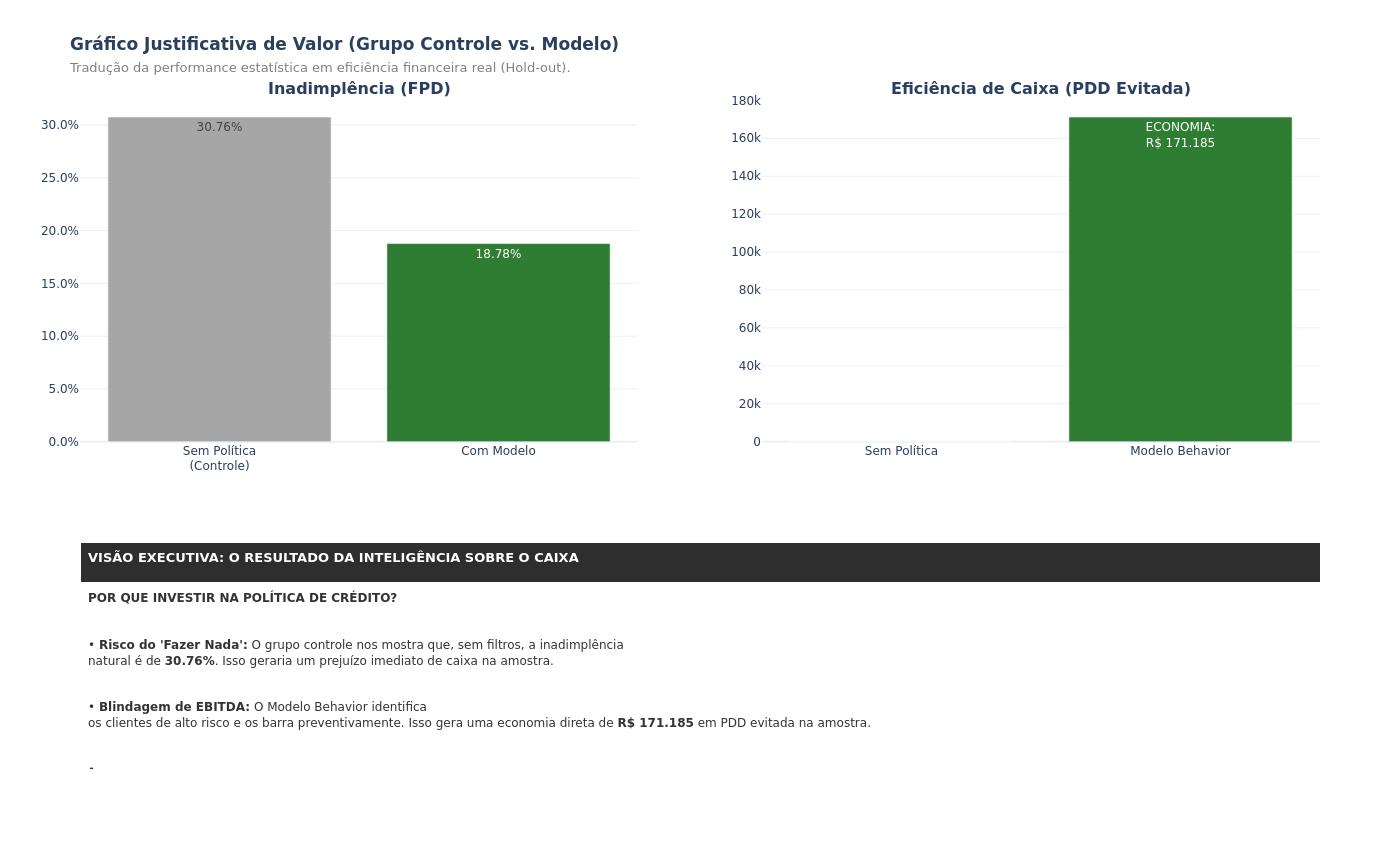

In [5]:
# ---------------------------------------------------------
# 00. O VALOR DA POLÍTICA: CENÁRIO "SEM POLÍTICA" VS "MODELO BEHAVIOR"
# FOCO: ECONOMIA GERADA E REDUÇÃO DE RISCO (CONTROLE ZZ/ZX)
# ---------------------------------------------------------


print("⚙️ Gerando Comparativo Real: Cenário Sem Política (Grupo Controle) vs Modelo...")

df_swap['rank_bur'] = df_swap['bur_score_02'].rank(method='first', ascending=False)
df_swap['rank_mod'] = df_swap['prob_modelo'].rank(method='first', ascending=True)


percentis_alvo = [50, 60, 70, 75, 80, 85, 90]
melhor_impacto = -np.inf
taxa_campea = "70%" 

for pct in percentis_alvo:
    n_aprov = int(len(df_swap) * (pct/100))
    mask_mod = df_swap['rank_mod'] <= n_aprov
    mask_bur = df_swap['rank_bur'] <= n_aprov
    
    # Modelo
    m_bads = df_swap.loc[mask_mod, 'target'].sum()
    m_goods = mask_mod.sum() - m_bads
    rec_mod = (m_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
              (m_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    # Bureau
    b_bads = df_swap.loc[mask_bur, 'target'].sum()
    b_goods = mask_bur.sum() - b_bads
    rec_bur = (b_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
              (b_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    if (rec_mod - rec_bur) > melhor_impacto:
        melhor_impacto = rec_mod - rec_bur
        taxa_campea = f"{pct}%"

# 1. CENÁRIO SEM POLÍTICA (Controle 100% Aprovação)
total_clientes_ctrl = len(df_swap)
total_bads_ctrl = df_swap['target'].sum()
fpd_sem_politica = total_bads_ctrl / total_clientes_ctrl
pdd_amostra_sem_politica = total_bads_ctrl * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA

# 2. CENÁRIO COM POLÍTICA (Modelo na Taxa Campeã)
taxa_aprov_num = float(taxa_campea.replace('%', '')) / 100
mask_mod = df_swap['rank_mod'] <= int(total_clientes_ctrl * taxa_aprov_num)
mod_bads = df_swap.loc[mask_mod, 'target'].sum()
fpd_com_politica = mod_bads / mask_mod.sum()
pdd_amostra_com_politica = mod_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA

# 3. A VITÓRIA FINANCEIRA (PDD EVITADA)
pdd_economizada = pdd_amostra_sem_politica - pdd_amostra_com_politica

def format_moeda_html(v):
    return f"R&#36; {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

fig = make_subplots(
    rows=2, cols=2,
    vertical_spacing=0.15,
    horizontal_spacing=0.1,
    row_heights=[0.6, 0.4],
    subplot_titles=("<b>Inadimplência (FPD)</b>", "<b>Eficiência de Caixa (PDD Evitada)</b>"),
    specs=[[{"type": "bar"}, {"type": "bar"}], [{"type": "table", "colspan": 2}, None]]
)

# Gráfico 1: Inadimplência 
fig.add_trace(go.Bar(
    x=['Sem Política<br>(Controle)', 'Com Modelo'],
    y=[fpd_sem_politica, fpd_com_politica],
    text=[f"{fpd_sem_politica:.2%}", f"{fpd_com_politica:.2%}"],
    textposition='auto',
    marker_color=['#A6A6A6', '#2E7D32'], 
    name='FPD'
), row=1, col=1)

# Gráfico 2: Dinheiro Salvo 
fig.add_trace(go.Bar(
    x=['Sem Política', 'Modelo Behavior'],
    y=[0, pdd_economizada],
    text=['R$ 0<br>(Base)', f'ECONOMIA:<br>{format_moeda_html(pdd_economizada)}'],
    textposition='auto',
    marker_color=['#4A4A4A', '#2E7D32'], # Cinza escuro vs Verde Sucesso
    name='PDD Salva'
), row=1, col=2)

racional = (
    "<b>POR QUE INVESTIR NA POLÍTICA DE CRÉDITO?</b><br><br>"
    f"• <b>Risco do 'Fazer Nada':</b> O grupo controle nos mostra que, sem filtros, a inadimplência natural é de <b>{fpd_sem_politica:.2%}</b>. "
    "Isso geraria um prejuízo imediato de caixa na amostra.<br><br>"
    f"• <b>Blindagem de EBITDA:</b> O Modelo Behavior identifica os clientes de alto risco e os barra preventivamente. "
    f"Isso gera uma economia direta de <b>{format_moeda_html(pdd_economizada)}</b> em PDD evitada na amostra.<br><br>"
    "• <b>Conclusão:</b> O modelo não é apenas uma ferramenta estatística, é um <b>seguro de margem</b> que garante que a Claro "
    "migre apenas os clientes com real capacidade de pagamento."
)

linhas = textwrap.wrap(racional, width=150)
texto_formatado = '<br>'.join(linhas).replace('<br>•', '<br><br>•')

fig.add_trace(go.Table(
    header=dict(values=["<b>VISÃO EXECUTIVA: O RESULTADO DA INTELIGÊNCIA SOBRE O CAIXA</b>"], 
                fill_color='#2E2E2E', align='left', font=dict(color='white', size=13), height=40),
    cells=dict(values=[[texto_formatado]], fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'), height=110)
), row=2, col=1)

fig.update_layout(
    title="<b>Gráfico Justificativa de Valor (Grupo Controle vs. Modelo)</b><br><span style='font-size:13px;color:gray'>Tradução da performance estatística em eficiência financeira real (Hold-out).</span>",
    height=850, width=1400, template="plotly_white", showlegend=False
)
fig.update_yaxes(tickformat='.1%', row=1, col=1)

fig.write_image(FIGURES_DIR / '00_valor_da_politica_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Calibrando Matriz de Assertividade: Modelo Behavior vs. Bureau (Fair-Play)...


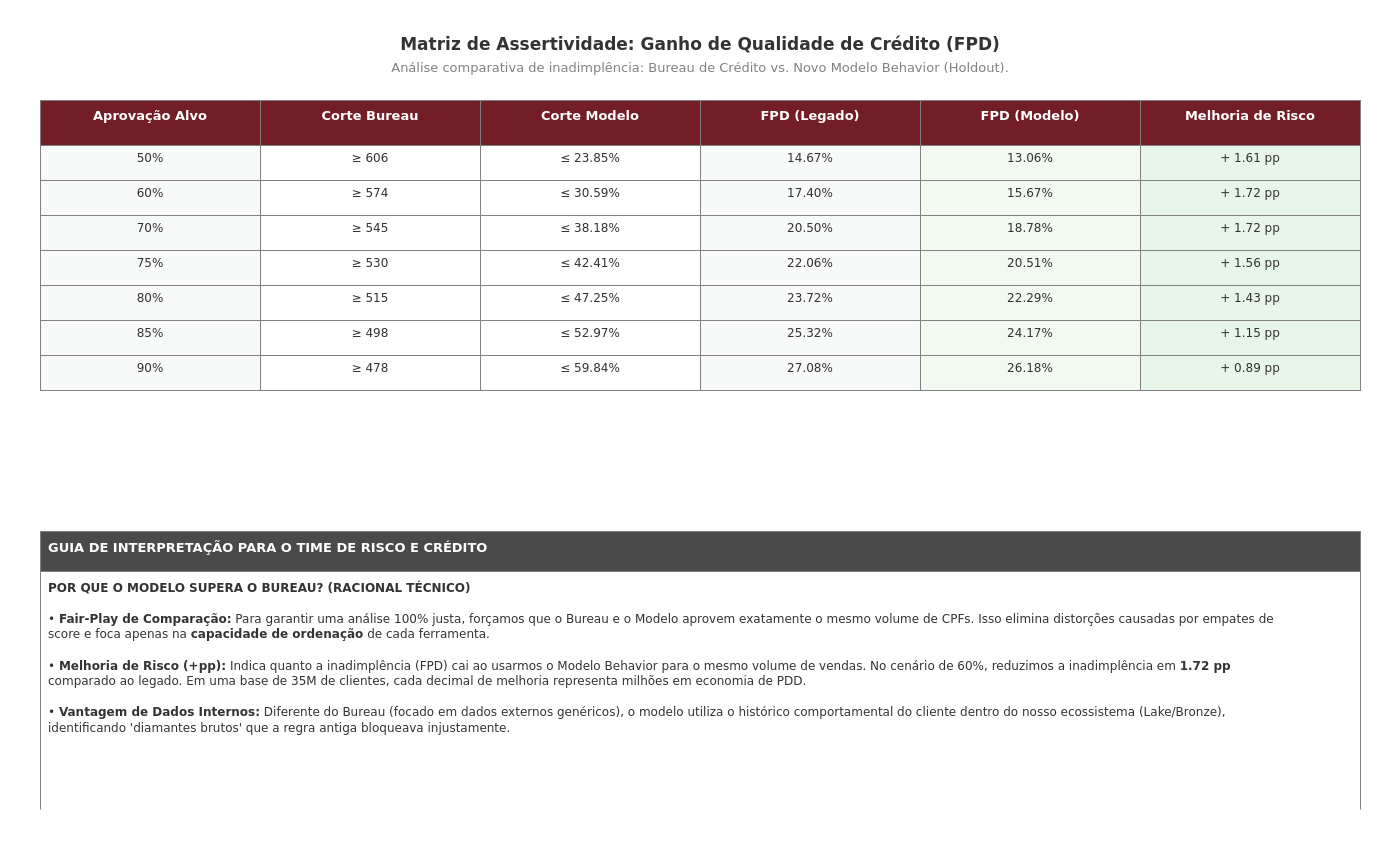

In [6]:
# ---------------------------------------------------------
# MATRIZ DE ASSERTIVIDADE E QUALIDADE TÉCNICA (FPD)
# ---------------------------------------------------------


print("⚙️ Calibrando Matriz de Assertividade: Modelo Behavior vs. Bureau (Fair-Play)...")



cenarios_tec = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90]
total_clientes = len(df_swap)

for pct in percentis_alvo:
    n_aprovados = int(total_clientes * (pct/100))
    
    mask_bur = df_swap['rank_bur'] <= n_aprovados
    mask_mod = df_swap['rank_mod'] <= n_aprovados
    
    cutoff_val_bur = df_swap.loc[df_swap['rank_bur'] == n_aprovados, 'bur_score_02'].values[0]
    cutoff_val_mod = df_swap.loc[df_swap['rank_mod'] == n_aprovados, 'prob_modelo'].values[0]
    
    br_bur = df_swap.loc[mask_bur, 'target'].mean()
    br_mod = df_swap.loc[mask_mod, 'target'].mean()
    
    cenarios_tec.append({
        'Aprovação': f"{pct}%",
        'Corte Bureau': f"≥ {cutoff_val_bur:.0f}",
        'Corte Modelo': f"≤ {cutoff_val_mod*100:.2f}%",
        'FPD (Bureau)': br_bur,
        'FPD (Modelo)': br_mod,
        'Ganho de Risco': br_bur - br_mod
    })

df_tec = pd.DataFrame(cenarios_tec)
melhor_ganho_pp = df_tec['Ganho de Risco'].max() * 100
melhor_pct = df_tec.loc[df_tec['Ganho de Risco'].idxmax(), 'Aprovação']

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.02,
    row_heights=[0.6, 0.4],
    specs=[[{"type": "table"}], [{"type": "table"}]]
)

fig.add_trace(go.Table(
    header=dict(
        values=["<b>Aprovação Alvo</b>", "<b>Corte Bureau</b>", "<b>Corte Modelo</b>", "<b>FPD (Legado)</b>", "<b>FPD (Modelo)</b>", "<b>Melhoria de Risco</b>"],
        fill_color='#731E27', align='center', font=dict(color='white', size=13), height=45
    ),
    cells=dict(
        values=[
            df_tec['Aprovação'], df_tec['Corte Bureau'], df_tec['Corte Modelo'],
            df_tec['FPD (Bureau)'].apply(lambda x: f"{x:.2%}"),
            df_tec['FPD (Modelo)'].apply(lambda x: f"{x:.2%}"),
            df_tec['Ganho de Risco'].apply(lambda x: f"+ {x*100:.2f} pp" if x > 0 else f"{x*100:.2f} pp")
        ],
        fill_color=['#F8F9F9', '#FFFFFF', '#FFFFFF', '#F8F9F9', '#F1F9F1', '#E8F5E9'],
        align='center', font=dict(size=12), height=35
    )
), row=1, col=1)

explica_tec = (
    "<b>POR QUE O MODELO SUPERA O BUREAU? (RACIONAL TÉCNICO)</b><br><br>"
    "• <b>Fair-Play de Comparação:</b> Para garantir uma análise 100% justa, forçamos que o Bureau e o Modelo aprovem exatamente o mesmo volume de CPFs. "
    "Isso elimina distorções causadas por empates de score e foca apenas na <b>capacidade de ordenação</b> de cada ferramenta.<br><br>"
    f"• <b>Melhoria de Risco (+pp):</b> Indica quanto a inadimplência (FPD) cai ao usarmos o Modelo Behavior para o mesmo volume de vendas. "
    f"No cenário de {melhor_pct}, reduzimos a inadimplência em <b>{melhor_ganho_pp:.2f} pp</b> comparado ao legado. Em uma base de {BASE_TOTAL_CLARO/1000000:.0f}M de clientes, "
    "cada decimal de melhoria representa milhões em economia de PDD.<br><br>"
    "• <b>Vantagem de Dados Internos:</b> Diferente do Bureau (focado em dados externos genéricos), o modelo utiliza o histórico comportamental do cliente dentro do nosso ecossistema (Lake/Bronze), "
    "identificando 'diamantes brutos' que a regra antiga bloqueava injustamente."
)

def wrap_paragraphs(text, width=30):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(explica_tec, width=200) 
altura_celula = texto_formatado.count('<br>') * 26 + 50

fig.add_trace(go.Table(
    header=dict(
        values=["<b>GUIA DE INTERPRETAÇÃO PARA O TIME DE RISCO E CRÉDITO</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Matriz de Assertividade: Ganho de Qualidade de Crédito (FPD)</b><br><span style='font-size:13px;color:gray'>Análise comparativa de inadimplência: Bureau de Crédito vs. Novo Modelo Behavior (Holdout).</span>",
    margin=dict(l=40, r=40, t=100, b=40), height=850, width=1400, paper_bgcolor='white'
)

fig.write_image(FIGURES_DIR / '01_matriz_assertividade_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Gerando Curvas de Densidade Probabilística (KDE)...


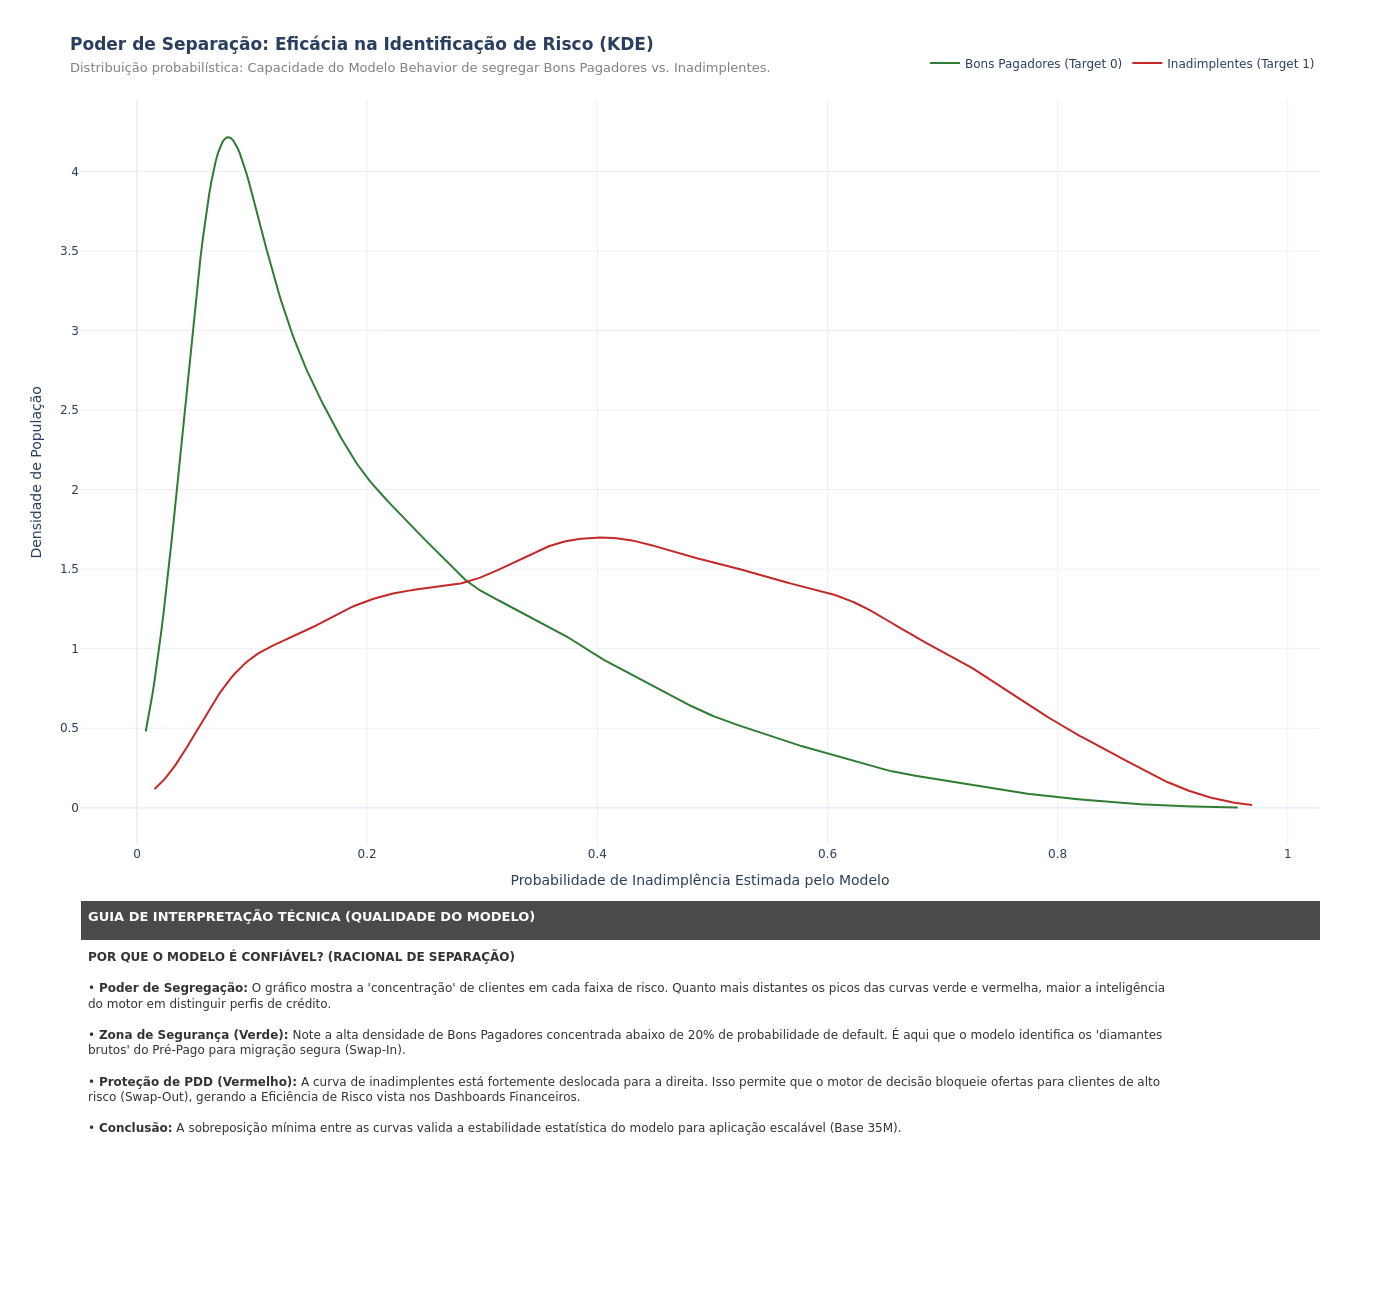

In [7]:
# ---------------------------------------------------------
# DENSIDADE DE SEPARAÇÃO: EFICÁCIA NA IDENTIFICAÇÃO DE RISCO
# ---------------------------------------------------------

print("⚙️ Gerando Curvas de Densidade Probabilística (KDE)...")

hist_data = [
    df_swap[df_swap['target'] == 0]['prob_modelo'], 
    df_swap[df_swap['target'] == 1]['prob_modelo']
]
group_labels = ['Bons Pagadores (Target 0)', 'Inadimplentes (Target 1)']
colors = ['#2E7D32', '#C62828'] 

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.05,
    row_heights=[0.7, 0.3],
    specs=[[{"type": "xy"}], [{"type": "table"}]]
)

fig_kde = ff.create_distplot(hist_data, group_labels, show_hist=False, colors=colors)

for trace in fig_kde.data:
    fig.add_trace(trace, row=1, col=1)

explica_separacao = (
    "<b>POR QUE O MODELO É CONFIÁVEL? (RACIONAL DE SEPARAÇÃO)</b><br><br>"
    "• <b>Poder de Segregação:</b> O gráfico mostra a 'concentração' de clientes em cada faixa de risco. "
    "Quanto mais distantes os picos das curvas verde e vermelha, maior a inteligência do motor em distinguir perfis de crédito.<br><br>"
    "• <b>Zona de Segurança (Verde):</b> Note a alta densidade de Bons Pagadores concentrada abaixo de 20% de probabilidade de default. "
    "É aqui que o modelo identifica os 'diamantes brutos' do Pré-Pago para migração segura (Swap-In).<br><br>"
    "• <b>Proteção de PDD (Vermelho):</b> A curva de inadimplentes está fortemente deslocada para a direita. Isso permite que o motor de decisão bloqueie "
    "ofertas para clientes de alto risco (Swap-Out), gerando a Eficiência de Risco vista nos Dashboards Financeiros.<br><br>"
    f"• <b>Conclusão:</b> A sobreposição mínima entre as curvas valida a estabilidade estatística do modelo para aplicação escalável (Base {BASE_TOTAL_CLARO/1000000:.0f}M)."
)

def wrap_paragraphs(text, width=100):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(explica_separacao, width=180)
altura_celula = texto_formatado.count('<br>') * 26 + 50

fig.add_trace(go.Table(
    header=dict(
        values=["<b>GUIA DE INTERPRETAÇÃO TÉCNICA (QUALIDADE DO MODELO)</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Poder de Separação: Eficácia na Identificação de Risco (KDE)</b><br><span style='font-size:13px;color:gray'>Distribuição probabilística: Capacidade do Modelo Behavior de segregar Bons Pagadores vs. Inadimplentes.</span>",
    height=1300, width=1400,
    xaxis_title="Probabilidade de Inadimplência Estimada pelo Modelo",
    yaxis_title="Densidade de População",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    paper_bgcolor='white',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig.write_image(FIGURES_DIR / '02_poder_separacao_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Executando Motor Financeiro (Visão LTV) | Conversão Calibrada: 4.98%


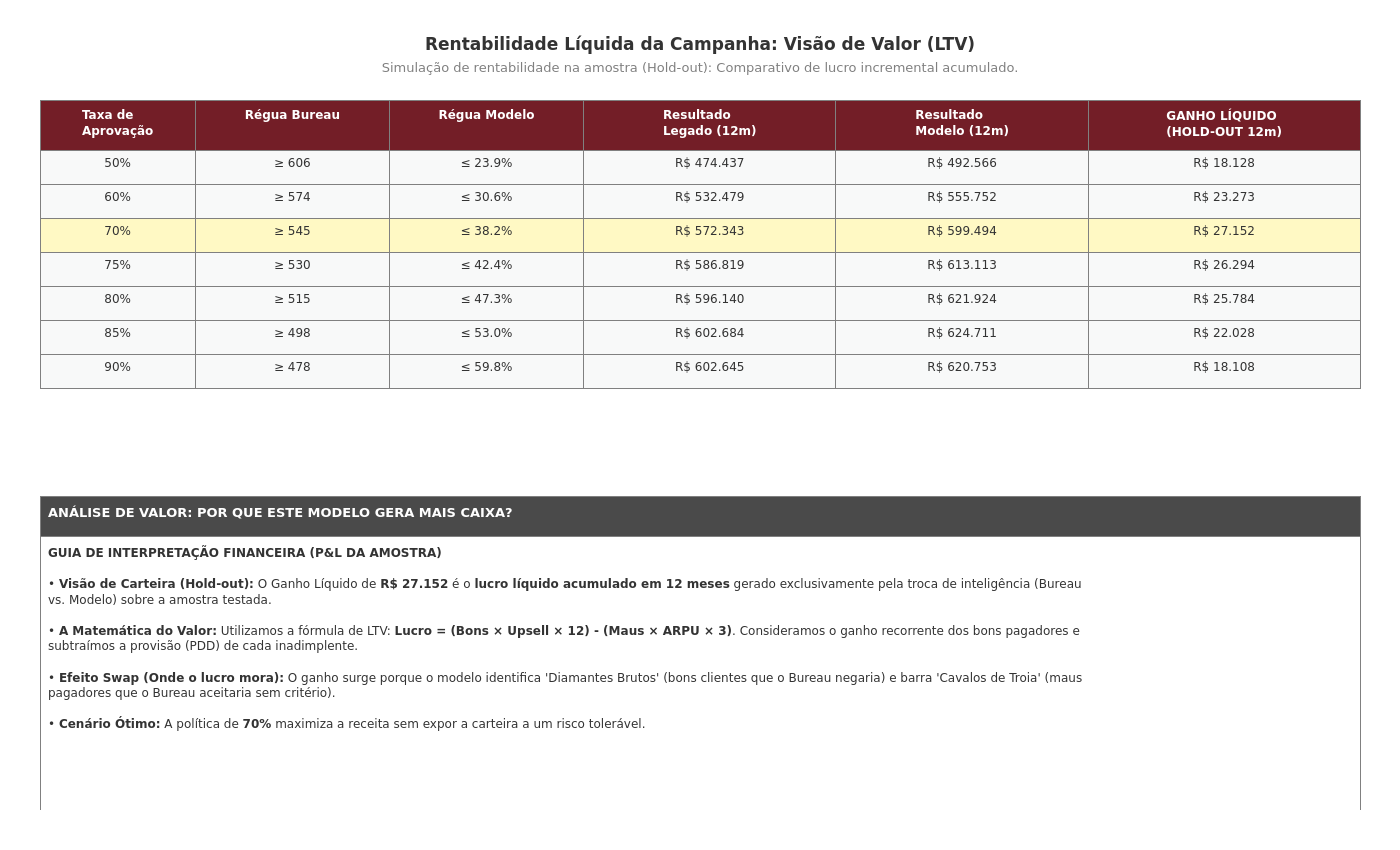

In [8]:
# ---------------------------------------------------------
# MOTOR DE DECISÃO E RENTABILIDADE LÍQUIDA (AMOSTRA)
# ---------------------------------------------------------


print(f"⚙️ Executando Motor Financeiro (Visão LTV) | Conversão Calibrada: {TAXA_CONVERSAO_AMOSTRA:.2%}")

df_swap['rank_bur'] = df_swap['bur_score_02'].rank(method='first', ascending=False)
df_swap['rank_mod'] = df_swap['prob_modelo'].rank(method='first', ascending=True)

cenarios_biz = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90]
total_clientes = len(df_swap)

for pct in percentis_alvo:
    n_aprovados = int(total_clientes * (pct/100))
    
    mask_bur = df_swap['rank_bur'] <= n_aprovados
    mask_mod = df_swap['rank_mod'] <= n_aprovados
    
    swap_in = (~mask_bur) & mask_mod
    swap_out = mask_bur & (~mask_mod)
    
    cutoff_val_bur = df_swap.loc[df_swap['rank_bur'] == n_aprovados, 'bur_score_02'].values[0]
    cutoff_val_mod = df_swap.loc[df_swap['rank_mod'] == n_aprovados, 'prob_modelo'].values[0]
    
    bur_goods = mask_bur.sum() - df_swap.loc[mask_bur, 'target'].sum()
    bur_bads = df_swap.loc[mask_bur, 'target'].sum()
    rec_legado = (bur_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
                 (bur_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    mod_goods = mask_mod.sum() - df_swap.loc[mask_mod, 'target'].sum()
    mod_bads = df_swap.loc[mask_mod, 'target'].sum()
    rec_modelo = (mod_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
                 (mod_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    cenarios_biz.append({
        'Taxa Aprovação': f"{pct}%",
        'Corte_Legado': cutoff_val_bur,
        'Corte_Modelo': cutoff_val_mod,
        'Receita_Legado': rec_legado,
        'Receita_Modelo': rec_modelo,
        'Impacto_Incremental': rec_modelo - rec_legado,
        'Vol_Swap_In': swap_in.sum(),
        'Vol_Swap_Out': swap_out.sum()
    })

df_biz = pd.DataFrame(cenarios_biz)

idx_otimo = df_biz['Impacto_Incremental'].idxmax()
taxa_campea = df_biz.loc[idx_otimo, 'Taxa Aprovação']

def format_moeda_br(v):
    return f"R$ {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

fig = make_subplots(
    rows=2, cols=1, 
    vertical_spacing=0.02, 
    row_heights=[0.55, 0.45], 
    specs=[[{"type": "table"}], [{"type": "table"}]]
)

row_colors = ['#F8F9F9'] * len(df_biz)
row_colors[idx_otimo] = '#FFF9C4' 

fig.add_trace(go.Table(
    columnwidth=[0.8, 1, 1, 1.3, 1.3, 1.4],
    header=dict(
        values=["<b>Taxa de<br>Aprovação</b>", "<b>Régua Bureau</b>", "<b>Régua Modelo</b>", "<b>Resultado<br>Legado (12m)</b>", "<b>Resultado<br>Modelo (12m)</b>", "<b>GANHO LÍQUIDO<br>(HOLD-OUT 12m)</b>"],
        fill_color='#731E27', align='center', font=dict(color='white', size=12), height=50
    ),
    cells=dict(
        values=[
            df_biz['Taxa Aprovação'], 
            df_biz['Corte_Legado'].apply(lambda x: f"≥ {x:.0f}"), 
            df_biz['Corte_Modelo'].apply(lambda x: f"≤ {x*100:.1f}%"),
            df_biz['Receita_Legado'].apply(format_moeda_br),
            df_biz['Receita_Modelo'].apply(format_moeda_br),
            df_biz['Impacto_Incremental'].apply(format_moeda_br)
        ],
        fill_color=[row_colors]*6, align='center', font=dict(size=12), height=34
    )
), row=1, col=1)

racional_executivo = (
    "<b>GUIA DE INTERPRETAÇÃO FINANCEIRA (P&L DA AMOSTRA)</b><br><br>"
    f"• <b>Visão de Carteira (Hold-out):</b> O Ganho Líquido de <b>{format_moeda_br(df_biz.loc[idx_otimo, 'Impacto_Incremental'])}</b> "
    f"é o <b>lucro líquido acumulado em {MESES_LTV} meses</b> gerado exclusivamente pela troca de inteligência (Bureau vs. Modelo) sobre a amostra testada.<br><br>"
    f"• <b>A Matemática do Valor:</b> Utilizamos a fórmula de LTV: "
    f"<b>Lucro = (Bons × Upsell × {MESES_LTV}) - (Maus × ARPU × {MESES_INADIMPLENCIA})</b>. "
    f"Consideramos o ganho recorrente dos bons pagadores e subtraímos a provisão (PDD) de cada inadimplente.<br><br>"
    f"• <b>Efeito Swap (Onde o lucro mora):</b> O ganho surge porque o modelo identifica 'Diamantes Brutos' (bons clientes que o Bureau negaria) "
    f"e barra 'Cavalos de Troia' (maus pagadores que o Bureau aceitaria sem critério).<br><br>"
    f"• <b>Cenário Ótimo:</b> A política de <b>{taxa_campea}</b> maximiza a receita sem expor a carteira a um risco tolerável."
)

def wrap_paragraphs(text, width=180):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(racional_executivo, width=180)
altura_celula = texto_formatado.count('<br>') * 26 + 60

fig.add_trace(go.Table(
    header=dict(
        values=["<b>ANÁLISE DE VALOR: POR QUE ESTE MODELO GERA MAIS CAIXA?</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Rentabilidade Líquida da Campanha: Visão de Valor (LTV)</b><br><span style='font-size:13px;color:gray'>Simulação de rentabilidade na amostra (Hold-out): Comparativo de lucro incremental acumulado.</span>",
    margin=dict(l=40, r=40, t=100, b=40), height=850, width=1400, paper_bgcolor='white'
)

fig.write_image(FIGURES_DIR / '03_retabilidade_liquida_amostra_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Gerando Curva de Acumulado (Fluxo de Caixa)...


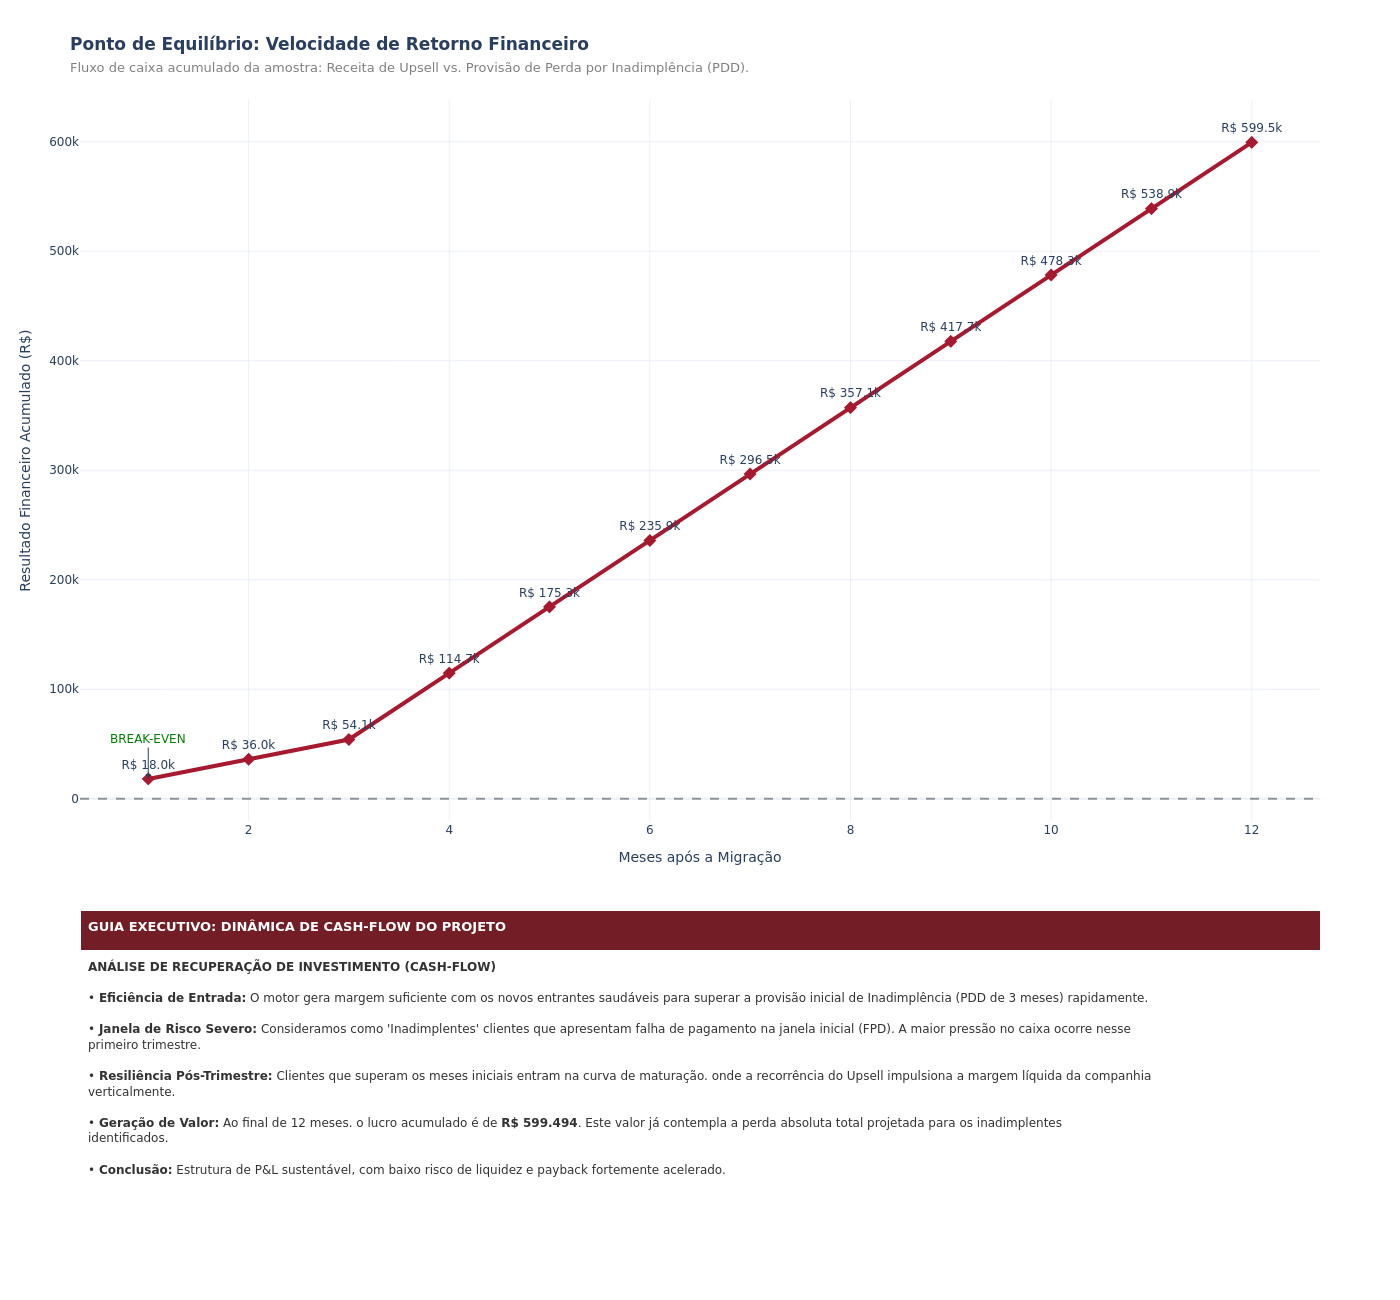

In [9]:
# ---------------------------------------------------------
# CURVA DE PAYBACK: CRONOGRAMA DE RETORNO FINANCEIRO (P&L)
# ---------------------------------------------------------


print("⚙️ Gerando Curva de Acumulado (Fluxo de Caixa)...")

taxa_aprovacao_otima = float(taxa_campea.replace('%', '')) / 100
n_aprovados = int(len(df_swap) * taxa_aprovacao_otima)

mask_mod = df_swap['rank_mod'] <= n_aprovados
mod_goods = mask_mod.sum() - df_swap.loc[mask_mod, 'target'].sum()
mod_bads = df_swap.loc[mask_mod, 'target'].sum()

# 2. CÁLCULO DO FLUXO DE CAIXA NO TEMPO
meses = np.arange(1, 13)
fluxo_acumulado = []

for m in meses:
    # Receita acumulada de Upsell (Recorrência mensal positiva)
    receita_upsell = mod_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * m
    
    # CORREÇÃO: Multiplicador de meses de inadimplência aplicado na PDD Total
    perda_total_pdd = mod_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA

    # Simulamos a "sangria" de caixa durante os meses de inadimplência
    perda_periodo = perda_total_pdd * (min(m, MESES_INADIMPLENCIA) / MESES_INADIMPLENCIA)
    
    # Saldo acumulado
    saldo = receita_upsell - (perda_total_pdd if m >= MESES_INADIMPLENCIA else perda_periodo)
    fluxo_acumulado.append(saldo)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.08,
    row_heights=[0.7, 0.3],
    specs=[[{"type": "xy"}], [{"type": "table"}]]
)

fig.add_trace(go.Scatter(
    x=meses, y=fluxo_acumulado,
    mode='lines+markers+text',
    name='Resultado Líquido Acumulado',
    text=[f"R$ {v/1000:.1f}k" for v in fluxo_acumulado],
    textposition="top center",
    line=dict(color='#A6192E', width=4),
    marker=dict(size=10, symbol='diamond', color='#A6192E')
), row=1, col=1)

fig.add_hline(y=0, line_dash="dash", line_color="#333333", opacity=0.5, row=1, col=1)

explica_payback = (
    "<b>ANÁLISE DE RECUPERAÇÃO DE INVESTIMENTO (CASH-FLOW)</b><br><br>"
    f"• <b>Eficiência de Entrada:</b> O motor gera margem suficiente com os novos entrantes saudáveis para "
    f"superar a provisão inicial de Inadimplência (PDD de {MESES_INADIMPLENCIA} meses) rapidamente.<br><br>"
    "• <b>Janela de Risco Severo:</b> Consideramos como 'Inadimplentes' clientes que apresentam falha de pagamento "
    "na janela inicial (FPD). A maior pressão no caixa ocorre nesse primeiro trimestre.<br><br>"
    "• <b>Resiliência Pós-Trimestre:</b> Clientes que superam os meses iniciais entram na curva de maturação, "
    "onde a recorrência do Upsell impulsiona a margem líquida da companhia verticalmente.<br><br>"
    f"• <b>Geração de Valor:</b> Ao final de {MESES_LTV} meses, o lucro acumulado é de <b>R$ {fluxo_acumulado[-1]:,.0f}</b>. ".replace(',', '.') + 
    "Este valor já contempla a perda absoluta total projetada para os inadimplentes identificados.<br><br>"
    "• <b>Conclusão:</b> Estrutura de P&L sustentável, com baixo risco de liquidez e payback fortemente acelerado."
)

def wrap_paragraphs(text, width=100):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(explica_payback, width=180)
altura_celula = texto_formatado.count('<br>') * 26 + 60

fig.add_trace(go.Table(
    header=dict(
        values=["<b>GUIA EXECUTIVO: DINÂMICA DE CASH-FLOW DO PROJETO</b>"],
        fill_color='#731E27', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Ponto de Equilíbrio: Velocidade de Retorno Financeiro</b><br><span style='font-size:13px;color:gray'>Fluxo de caixa acumulado da amostra: Receita de Upsell vs. Provisão de Perda por Inadimplência (PDD).</span>",
    height=1300, width=1400,
    xaxis_title="Meses após a Migração",
    yaxis_title="Resultado Financeiro Acumulado (R$)",
    template="plotly_white",
    paper_bgcolor='white'
)

# Adicionamos uma verificação pra colocar a anotação no break-even correto
mes_breakeven = next((i for i, v in enumerate(fluxo_acumulado) if v > 0), 0) + 1
fig.add_annotation(
    x=mes_breakeven, y=fluxo_acumulado[mes_breakeven-1], text="BREAK-EVEN",
    showarrow=True, arrowhead=2, ax=0, ay=-40, font=dict(color="green", size=12), bgcolor="white"
)

fig.write_image(FIGURES_DIR / '04_receita_upsell_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Gerando Curva de Custo do Erro (Trade-off Falsos Positivos vs Negativos)...


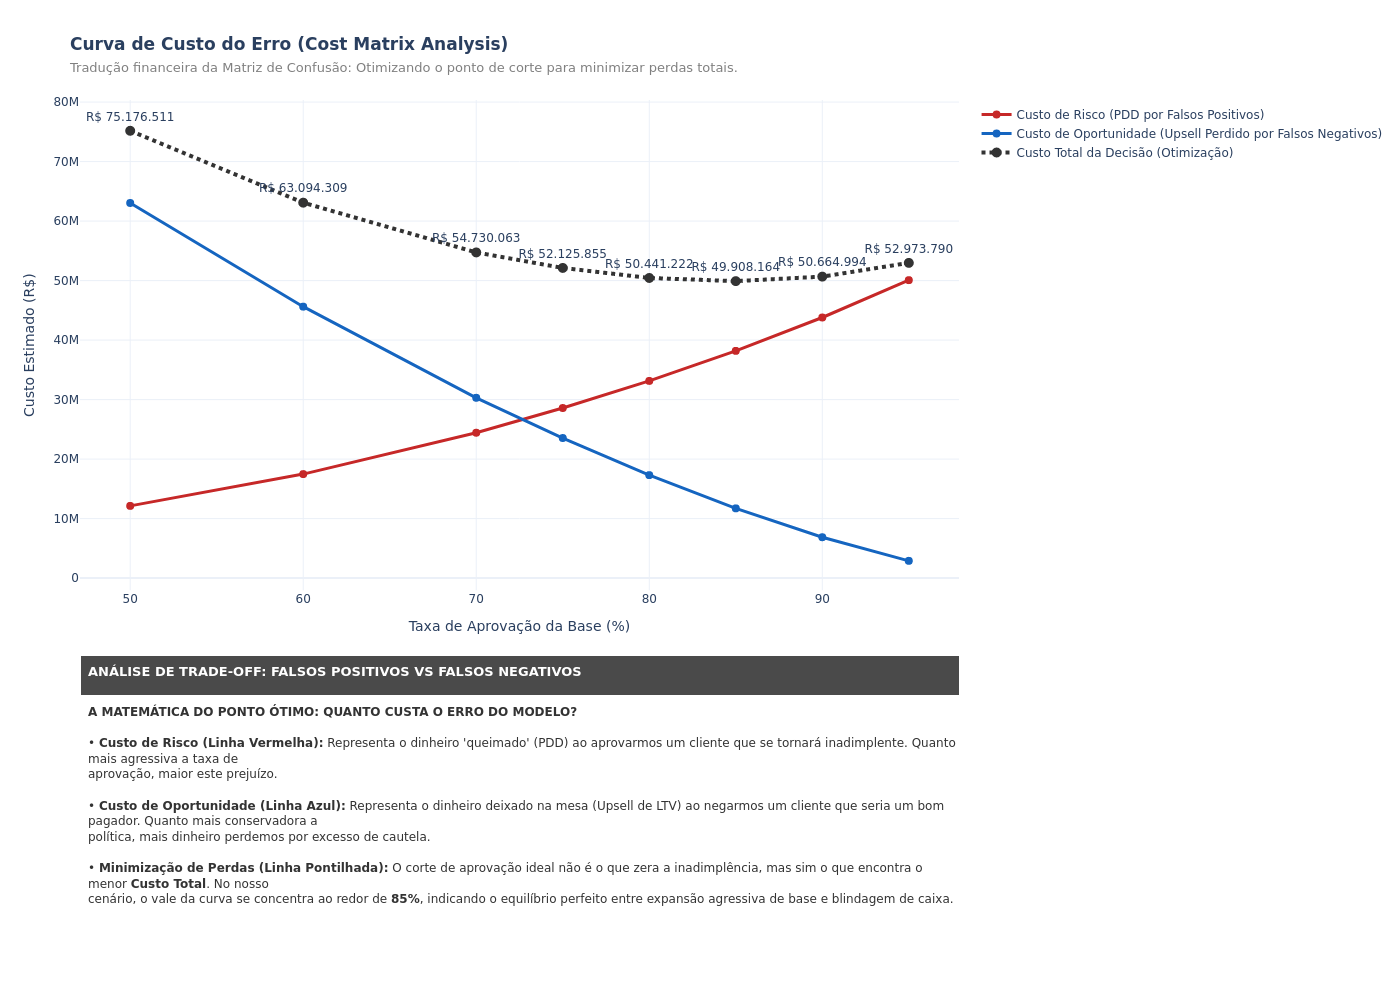

In [10]:
# ---------------------------------------------------------
# CUSTO DO ERRO: TRADE-OFF ENTRE FRAUDE E PERDA DE OPORTUNIDADE
# ---------------------------------------------------------


print("⚙️ Gerando Curva de Custo do Erro (Trade-off Falsos Positivos vs Negativos)...")

fator_escala = BASE_TOTAL_CLARO / len(df_swap)

def format_moeda_html(v):
    return f"R&#36; {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

def wrap_paragraphs(text, width=180):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)
# --------------------------------------------------------------------------

cenarios_custo = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90, 95]

for pct in percentis_alvo:
    n_aprovados = int(len(df_swap) * (pct/100))
    mask_mod = df_swap['rank_mod'] <= n_aprovados
    
    # Falsos Positivos: Aprovamos, mas era Inadimplente (Custo = PDD)
    fp_vol = df_swap.loc[mask_mod, 'target'].sum() * fator_escala * TAXA_CONVERSAO_META
    custo_fp = fp_vol * ARPU_CONTROLE * MESES_INADIMPLENCIA
    
    # Falsos Negativos: Negamos, mas era Bom Pagador (Custo = Upsell Perdido)
    fn_vol = (~mask_mod).sum() - df_swap.loc[~mask_mod, 'target'].sum()
    fn_vol = fn_vol * fator_escala * TAXA_CONVERSAO_META
    custo_fn = fn_vol * UPSELL * MESES_LTV
    
    custo_total = custo_fp + custo_fn
    
    cenarios_custo.append({
        'Aprovação': pct,
        'Custo_Risco (FP)': custo_fp,
        'Custo_Oportunidade (FN)': custo_fn,
        'Custo_Total': custo_total
    })

df_custo = pd.DataFrame(cenarios_custo)
melhor_corte_custo = df_custo.loc[df_custo['Custo_Total'].idxmin(), 'Aprovação']

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.08,
    row_heights=[0.65, 0.35],
    specs=[[{"type": "xy"}], [{"type": "table"}]]
)

fig.add_trace(go.Scatter(
    x=df_custo['Aprovação'], y=df_custo['Custo_Risco (FP)'],
    mode='lines+markers', name='Custo de Risco (PDD por Falsos Positivos)',
    line=dict(color='#C62828', width=3), marker=dict(size=8)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_custo['Aprovação'], y=df_custo['Custo_Oportunidade (FN)'],
    mode='lines+markers', name='Custo de Oportunidade (Upsell Perdido por Falsos Negativos)',
    line=dict(color='#1565C0', width=3), marker=dict(size=8)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_custo['Aprovação'], y=df_custo['Custo_Total'],
    mode='lines+markers+text', name='Custo Total da Decisão (Otimização)',
    text=[format_moeda_html(v) for v in df_custo['Custo_Total']],
    textposition="top center",
    line=dict(color='#333333', width=4, dash='dot'), marker=dict(size=10)
), row=1, col=1)

racional_custo = (
    "<b>A MATEMÁTICA DO PONTO ÓTIMO: QUANTO CUSTA O ERRO DO MODELO?</b><br><br>"
    "• <b>Custo de Risco (Linha Vermelha):</b> Representa o dinheiro 'queimado' (PDD) ao aprovarmos um cliente que se tornará inadimplente. "
    "Quanto <br>mais agressiva a taxa de aprovação, maior este prejuízo.<br><br>"
    "• <b>Custo de Oportunidade (Linha Azul):</b> Representa o dinheiro deixado na mesa (Upsell de LTV) ao negarmos um cliente que seria um bom <br>pagador. "
    "Quanto mais conservadora a política, mais dinheiro perdemos por excesso de cautela.<br><br>"
    f"• <b>Minimização de Perdas (Linha Pontilhada):</b> O corte de aprovação ideal não é o que zera a inadimplência, mas sim o que encontra o <br>"
    f"menor <b>Custo Total</b>. No nosso cenário, o vale da curva se concentra ao redor de <b>{melhor_corte_custo}%</b>, indicando o equilíbrio perfeito "
    "entre expansão agressiva de base e blindagem de caixa."
)

texto_formatado = wrap_paragraphs(racional_custo, width=180)
altura_celula = texto_formatado.count('<br>') * 26 + 50

fig.add_trace(go.Table(
    header=dict(
        values=["<b>ANÁLISE DE TRADE-OFF: FALSOS POSITIVOS VS FALSOS NEGATIVOS</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Curva de Custo do Erro (Cost Matrix Analysis)</b><br><span style='font-size:13px;color:gray'>Tradução financeira da Matriz de Confusão: Otimizando o ponto de corte para minimizar perdas totais.</span>",
    height=1000, width=1400,
    xaxis_title="Taxa de Aprovação da Base (%)",
    yaxis_title="Custo Estimado (R$)",
    template="plotly_white",
    hovermode="x unified"
)

fig.write_image(FIGURES_DIR / '05_custo_do_erro_v1.png', scale=2)
fig.show(renderer='png')

🚀 Gerando Dashboard Nacional (Extrapolação via Ranking Fair-Play)...


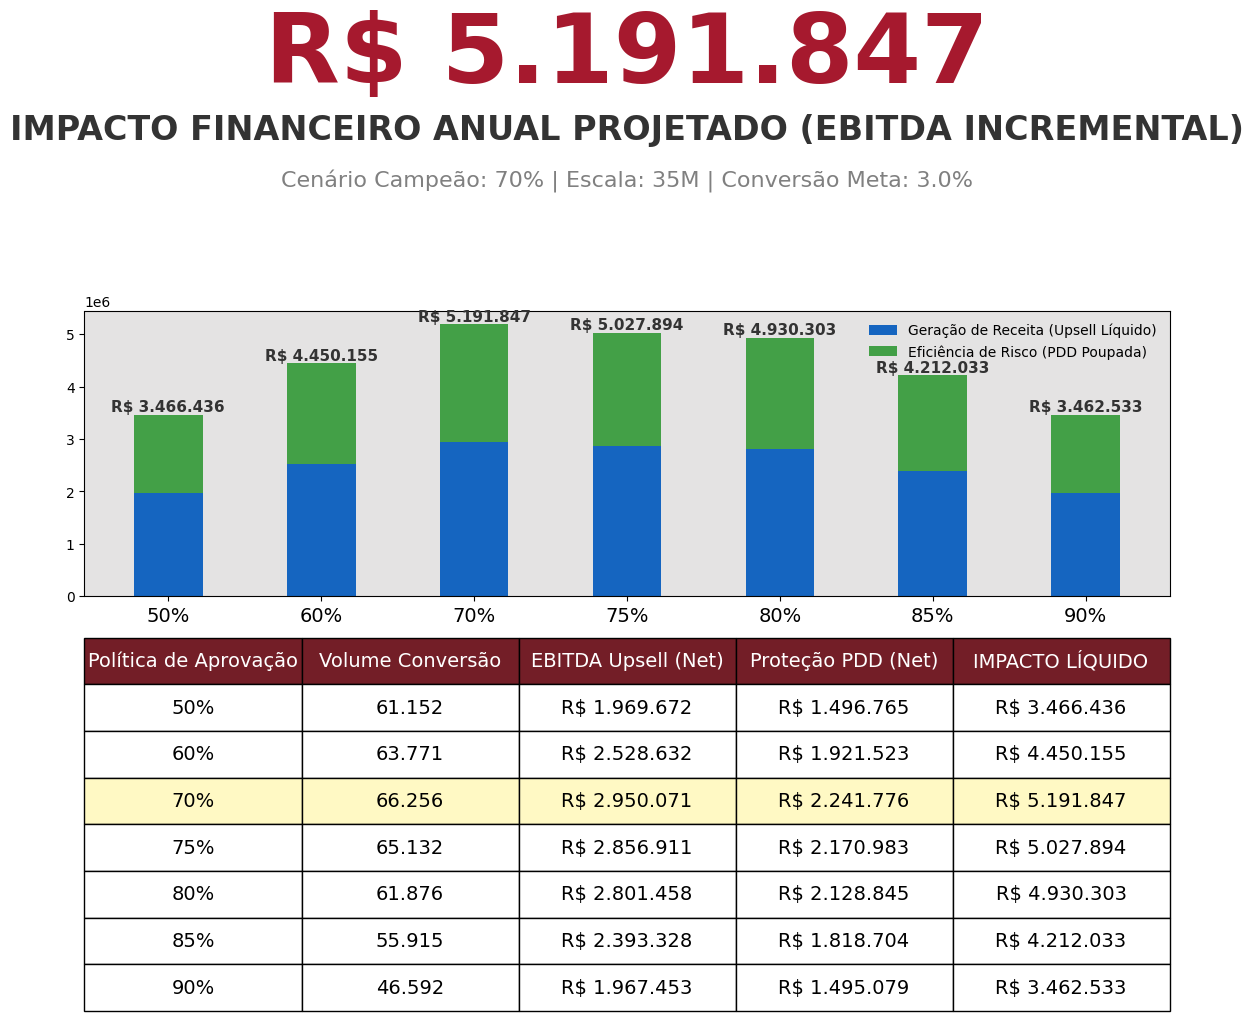

In [11]:
# ---------------------------------------------------------
# DASHBOARD EXECUTIVO NACIONAL (PROJEÇÃO DE EBITDA) - VALORES REAIS
# ---------------------------------------------------------


def format_moeda(v):
    return f"R$ {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print("🚀 Gerando Dashboard Nacional (Extrapolação via Ranking Fair-Play)...")

n_amostra = len(df_swap)
fator_escala = BASE_TOTAL_CLARO / n_amostra

cenarios_nac = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90]

for pct in percentis_alvo:
    n_aprov = int(len(df_swap) * (pct/100)) 
    mask_bur = df_swap['rank_bur'] <= n_aprov
    mask_mod = df_swap['rank_mod'] <= n_aprov
    
    swap_in = (~mask_bur) & mask_mod
    swap_out = mask_bur & (~mask_mod)
    
    in_goods = swap_in.sum() - df_swap.loc[swap_in, 'target'].sum()
    in_bads = df_swap.loc[swap_in, 'target'].sum()
    out_goods = swap_out.sum() - df_swap.loc[swap_out, 'target'].sum()
    out_bads = df_swap.loc[swap_out, 'target'].sum()
    
    lucro_in_nac = ((in_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV) - 
                    (in_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * MESES_INADIMPLENCIA))
    
    econ_out_nac = ((out_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * MESES_INADIMPLENCIA) - 
                    (out_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV))
    
    total_real = lucro_in_nac + econ_out_nac
    
    # CORREÇÃO CRÍTICA: Upsell e Risco calculados em base líquida (NET) para não esconder perdas do swap-out
    upsell_net_nac = ((in_goods - out_goods) * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV)
    risco_net_nac = ((out_bads - in_bads) * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * MESES_INADIMPLENCIA)

    cenarios_nac.append({
        'Aprovação': f"{pct}%",
        'Conv_Vol': (swap_in.sum() * fator_escala * TAXA_CONVERSAO_META),
        'Upsell_Net': upsell_net_nac,
        'PDD_Net': risco_net_nac,
        'Total_Real': total_real
    })

df_report_nac = pd.DataFrame(cenarios_nac)
idx_otimo = df_report_nac['Total_Real'].idxmax()
dados_otimos = df_report_nac.loc[idx_otimo]

fig = plt.figure(figsize=(14, 16), dpi=100, facecolor='white')
gs = GridSpec(4, 1, height_ratios=[0.8, 1.2, 1.2, 0.9], hspace=0.35)

ax0 = fig.add_subplot(gs[0]); ax0.axis('off')
ax0.text(0.5, 0.75, format_moeda(dados_otimos['Total_Real']), fontsize=70, color='#A6192E', ha='center', fontweight='bold')
ax0.text(0.5, 0.45, 'IMPACTO FINANCEIRO ANUAL PROJETADO (EBITDA INCREMENTAL)', fontsize=24, ha='center', color='#333333', fontweight='bold')
ax0.text(0.5, 0.20, f"Cenário Campeão: {dados_otimos['Aprovação']} | Escala: {BASE_TOTAL_CLARO/1000000:.0f}M | Conversão Meta: {TAXA_CONVERSAO_META:.1%}", fontsize=16, ha='center', color='gray')

ax1 = fig.add_subplot(gs[1])
x_pos = np.arange(len(df_report_nac['Aprovação']))
# Utilizando as variáveis Net corrigidas
ax1.bar(x_pos, df_report_nac['Upsell_Net'], color='#1565C0', label='Geração de Receita (Upsell Líquido)', width=0.45)
ax1.bar(x_pos, df_report_nac['PDD_Net'], bottom=df_report_nac['Upsell_Net'], color='#43A047', label='Eficiência de Risco (PDD Poupada)', width=0.45)
ax1.set_xticks(x_pos); ax1.set_xticklabels(df_report_nac['Aprovação'], fontsize=14); ax1.legend(loc='upper right', frameon=False)

for i, total in enumerate(df_report_nac['Total_Real']):
    ax1.text(i, total, format_moeda(total), ha='center', fontweight='bold', fontsize=11, color='#333333', va='bottom')

ax2 = fig.add_subplot(gs[2]); ax2.axis('off')
table_data = [[r['Aprovação'], f"{r['Conv_Vol']:,.0f}".replace(',', '.'), format_moeda(r['Upsell_Net']), format_moeda(r['PDD_Net']), format_moeda(r['Total_Real'])] for _, r in df_report_nac.iterrows()]
tbl = ax2.table(cellText=table_data, colLabels=['Política de Aprovação', 'Volume Conversão', 'EBITDA Upsell (Net)', 'Proteção PDD (Net)', 'IMPACTO LÍQUIDO'], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(14); tbl.scale(1, 2.8)

for j in range(5):
    tbl[0, j].set_facecolor('#731E27'); tbl[0, j].get_text().set_color('white')
    tbl[idx_otimo + 1, j].set_facecolor('#FFF9C4')

plt.savefig(FIGURES_DIR / '06_ebitida_impacto_geral_v1.png', dpi=100)
plt.show()

⚙️ Gerando Waterfall de Conciliação Financeira (Bridge de EBITDA)...


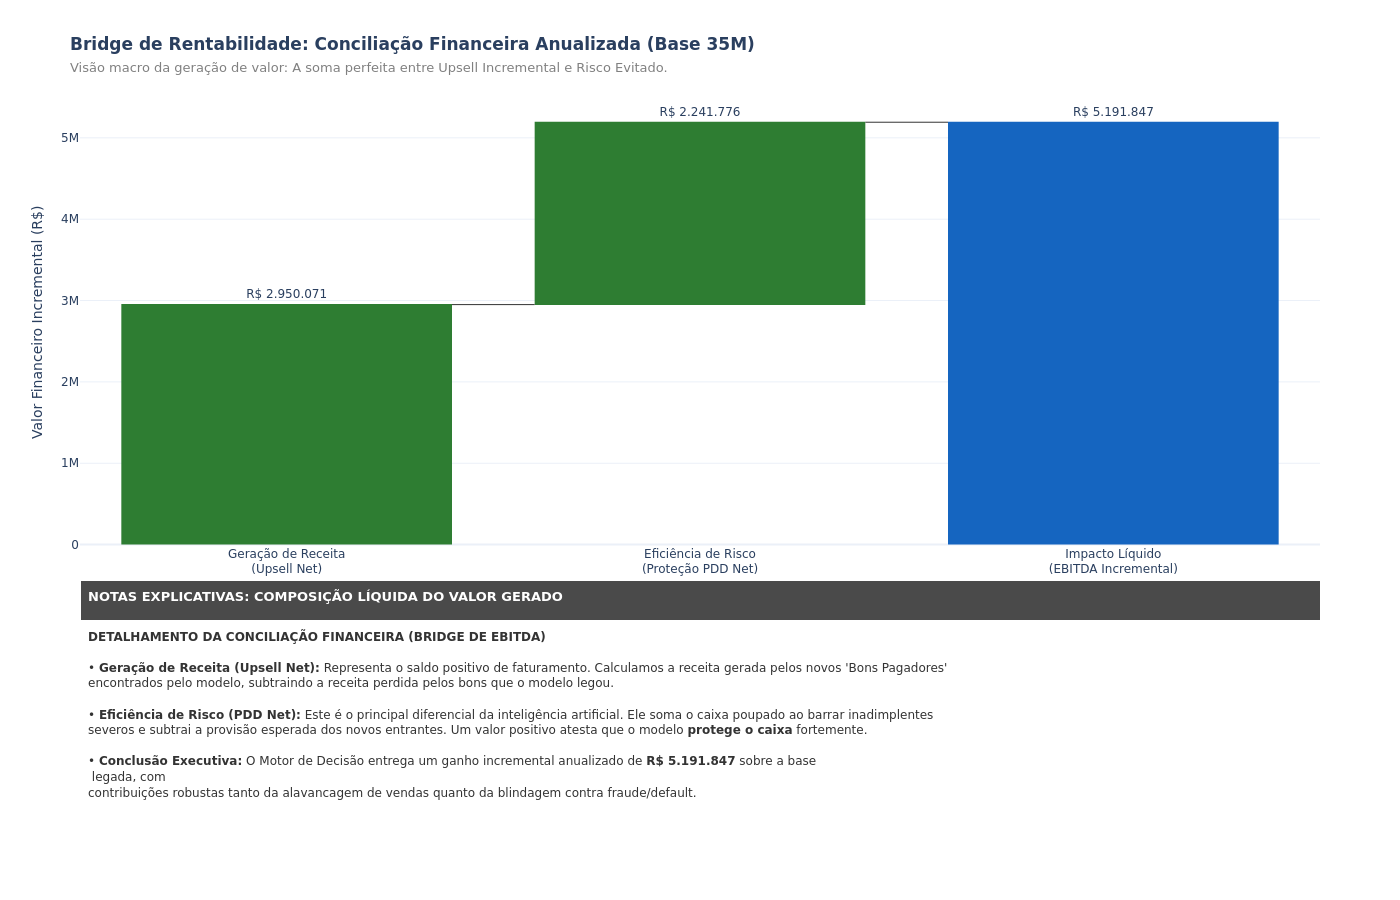

In [12]:
# ---------------------------------------------------------
# CONCILIAÇÃO DE VALOR: BRIDGE DE EBITDA (NACIONAL)
# ---------------------------------------------------------


def format_moeda(v):
    return f"R$ {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print("⚙️ Gerando Waterfall de Conciliação Financeira (Bridge de EBITDA)...")

total_final = dados_otimos['Total_Real']
upsell_net_final = dados_otimos['Upsell_Net']
pdd_net_final = dados_otimos['PDD_Net']

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.05,
    row_heights=[0.65, 0.35],
    specs=[[{"type": "xy"}], [{"type": "table"}]]
)

fig.add_trace(go.Waterfall(
    name="Bridge", 
    orientation="v",
    measure=["relative", "relative", "total"],
    x=["Geração de Receita<br>(Upsell Net)", "Eficiência de Risco<br>(Proteção PDD Net)", "Impacto Líquido<br>(EBITDA Incremental)"],
    y=[upsell_net_final, pdd_net_final, 0],
    text=[format_moeda(upsell_net_final), format_moeda(pdd_net_final), format_moeda(total_final)],
    textposition="outside",
    connector={"line": {"color": "#333333", "width": 1}},
    increasing={"marker": {"color": "#2E7D32"}}, 
    decreasing={"marker": {"color": "#C62828"}}, 
    totals={"marker": {"color": "#1565C0"}}
), row=1, col=1)

racional_waterfall = (
    "<b>DETALHAMENTO DA CONCILIAÇÃO FINANCEIRA (BRIDGE DE EBITDA)</b><br><br>"
    "• <b>Geração de Receita (Upsell Net):</b> Representa o saldo positivo de faturamento. Calculamos a receita gerada pelos "
    "novos 'Bons Pagadores' encontrados pelo modelo, subtraindo a receita perdida pelos bons que o modelo legou.<br><br>"
    "• <b>Eficiência de Risco (PDD Net):</b> Este é o principal diferencial da inteligência artificial. Ele soma o caixa poupado "
    "ao barrar inadimplentes severos e subtrai a provisão esperada dos novos entrantes. Um valor positivo atesta que o modelo <b>protege o caixa</b> fortemente.<br><br>"
    f"• <b>Conclusão Executiva:</b> O Motor de Decisão entrega um ganho incremental anualizado de <b>{format_moeda(total_final)}</b> "
    "sobre a base<br> legada, com contribuições robustas tanto da alavancagem de vendas quanto da blindagem contra fraude/default."
)

def wrap_paragraphs(text, width=100):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(racional_waterfall, width=150)
altura_celula = texto_formatado.count('<br>') * 26 + 60

fig.add_trace(go.Table(
    header=dict(
        values=["<b>NOTAS EXPLICATIVAS: COMPOSIÇÃO LÍQUIDA DO VALOR GERADO</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title=f"<b>Bridge de Rentabilidade: Conciliação Financeira Anualizada (Base {BASE_TOTAL_CLARO/1000000:.0f}M)</b><br><span style='font-size:13px;color:gray'>Visão macro da geração de valor: A soma perfeita entre Upsell Incremental e Risco Evitado.</span>",
    height=900, width=1400,
    yaxis_title="Valor Financeiro Incremental (R$)",
    template="plotly_white",
    paper_bgcolor='white'
)

fig.write_image(FIGURES_DIR / '07_conciliacao_financeira_geral_v1.png', scale=2)
fig.show(renderer='png')

⚡ Executando Stress Test de Resiliência Financeira (Cenário Nacional)...


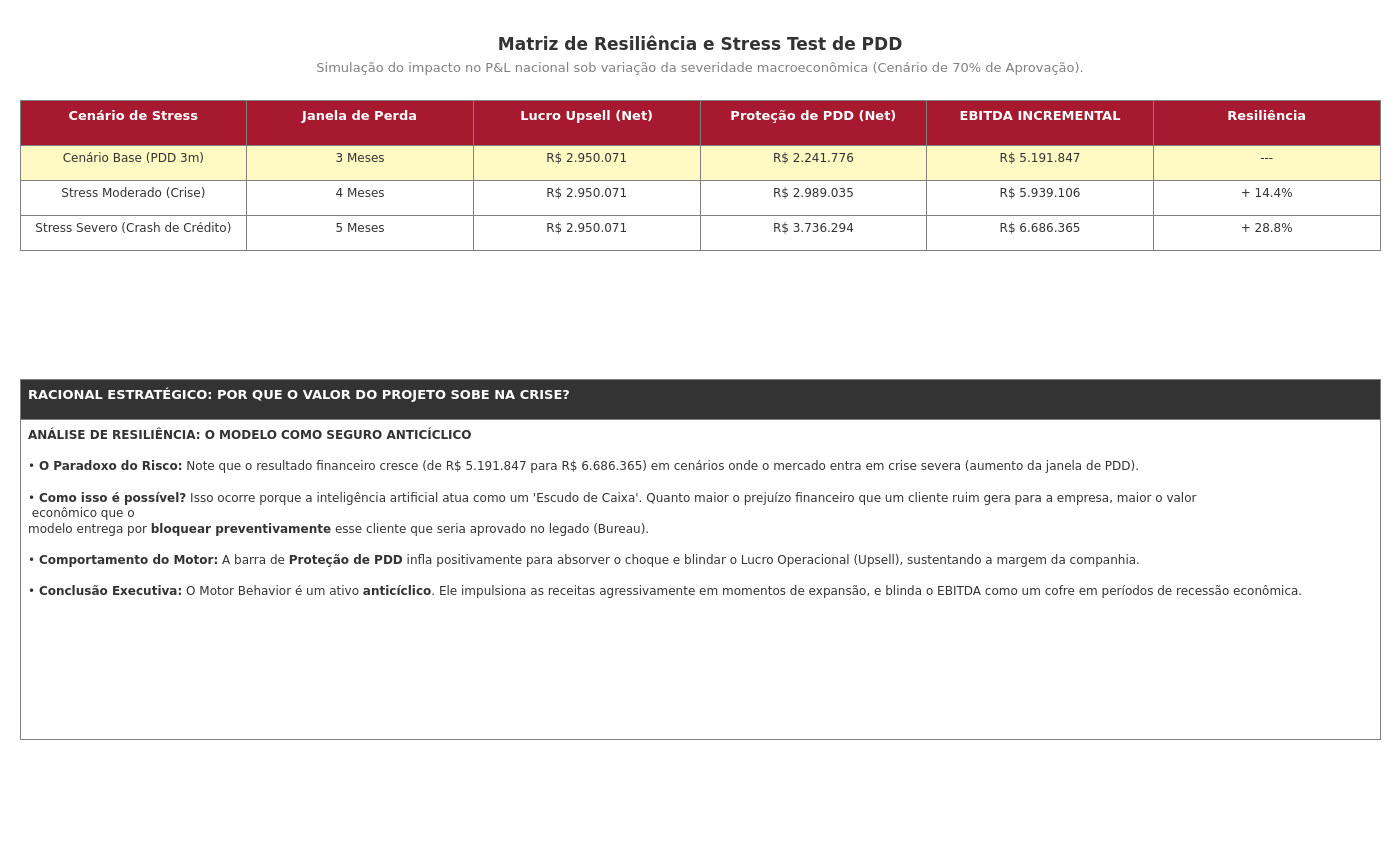

In [13]:
# ---------------------------------------------------------
# MATRIZ DE RESILIÊNCIA E STRESS TEST DE PDD
# ---------------------------------------------------------


def format_moeda(v):
    return f"R$ {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print("⚡ Executando Stress Test de Resiliência Financeira (Cenário Nacional)...")

taxa_aprov_num = float(taxa_campea.replace('%', '')) / 100
n_aprovados = int(len(df_swap) * taxa_aprov_num)

mask_bur = df_swap['rank_bur'] <= n_aprovados
mask_mod = df_swap['rank_mod'] <= n_aprovados

swap_in = (~mask_bur) & mask_mod
swap_out = mask_bur & (~mask_mod)

s_in_goods = swap_in.sum() - df_swap.loc[swap_in, 'target'].sum()
s_in_bads = df_swap.loc[swap_in, 'target'].sum()
s_out_goods = swap_out.sum() - df_swap.loc[swap_out, 'target'].sum()
s_out_bads = df_swap.loc[swap_out, 'target'].sum()

cenarios_pdd = [
    {'Meses': MESES_INADIMPLENCIA, 'Descricao': f'Cenário Base (PDD {MESES_INADIMPLENCIA}m)'},
    {'Meses': MESES_INADIMPLENCIA + 1, 'Descricao': 'Stress Moderado (Crise)'},
    {'Meses': MESES_INADIMPLENCIA + 2, 'Descricao': 'Stress Severo (Crash de Crédito)'}
]

resultados_sensibilidade = []

# CÁLCULO ALINHADO: Upsell Net considera as perdas do swap-out, garantindo alinhamento com Waterfall
upsell_net_base = ((s_in_goods - s_out_goods) * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV)

for cenario in cenarios_pdd:
    m_loss = cenario['Meses']
    
    lucro_in = ((s_in_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV) - 
                (s_in_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * m_loss))
    
    prot_out = ((s_out_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * m_loss) - 
                (s_out_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV))
    
    total_real = lucro_in + prot_out
    
    # Risco Net reage proporcionalmente à piora do mercado (aumento do m_loss)
    risco_net = ((s_out_bads - s_in_bads) * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * m_loss)
    
    if cenario['Descricao'].startswith('Cenário Base'):
        base_real_st = total_real
        variacao = "---"
    else:
        pct_change = ((total_real / base_real_st) - 1) * 100
        variacao = f"+ {pct_change:.1f}%"
        
    resultados_sensibilidade.append({
        'Cenário de Stress': cenario['Descricao'],
        'Janela de Perda': f"{m_loss} Meses",
        'Lucro Upsell (Net)': format_moeda(upsell_net_base), 
        'Proteção de PDD': format_moeda(risco_net),       
        'EBITDA INCREMENTAL': format_moeda(total_real),
        'Ganho de Resiliência': variacao
    })
    
    if m_loss == cenarios_pdd[-1]['Meses']: stress_real_max = total_real

df_sens = pd.DataFrame(resultados_sensibilidade)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.05,
    row_heights=[0.35, 0.65],
    specs=[[{"type": "table"}], [{"type": "table"}]]
)

fig.add_trace(go.Table(
    header=dict(
        values=["<b>Cenário de Stress</b>", "<b>Janela de Perda</b>", "<b>Lucro Upsell (Net)</b>", "<b>Proteção de PDD (Net)</b>", "<b>EBITDA INCREMENTAL</b>", "<b>Resiliência</b>"],
        fill_color='#A6192E', align='center', font=dict(color='white', size=13), height=45
    ),
    cells=dict(
        values=[df_sens[c] for c in df_sens.columns],
        fill_color=[['#FFF9C4', '#FFFFFF', '#FFFFFF'] * len(df_sens)],
        align='center', font=dict(size=12), height=35
    )
), row=1, col=1)

def format_moeda_html(v):
    # Usa o código HTML &#36; para o cifrão, evitando o gatilho do LaTeX no Plotly
    return f"R&#36; {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

racional_stress = (
    "<b>ANÁLISE DE RESILIÊNCIA: O MODELO COMO SEGURO ANTICÍCLICO</b><br><br>"
    f"• <b>O Paradoxo do Risco:</b> Note que o resultado financeiro cresce (de {format_moeda_html(base_real_st)} para {format_moeda_html(stress_real_max)}) "
    "em cenários onde o mercado entra em crise severa (aumento da janela de PDD).<br><br>"
    "• <b>Como isso é possível?</b> Isso ocorre porque a inteligência artificial atua como um 'Escudo de Caixa'. Quanto maior o prejuízo financeiro "
    "que um cliente ruim gera para a empresa, maior o valor<br> econômico que o modelo entrega por <b>bloquear preventivamente</b> esse cliente "
    "que seria aprovado no legado (Bureau).<br><br>"
    "• <b>Comportamento do Motor:</b> A barra de <b>Proteção de PDD</b> infla positivamente para absorver o choque e blindar o "
    "Lucro Operacional (Upsell), sustentando a margem da companhia.<br><br>"
    "• <b>Conclusão Executiva:</b> O Motor Behavior é um ativo <b>anticíclico</b>. Ele impulsiona as receitas agressivamente em momentos de expansão, "
    "e blinda o EBITDA como um cofre em períodos de recessão econômica."
)

def wrap_paragraphs(text, width=100):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(racional_stress, width=220)
altura_celula = texto_formatado.count('<br>') * 26 + 60

fig.add_trace(go.Table(
    header=dict(
        values=["<b>RACIONAL ESTRATÉGICO: POR QUE O VALOR DO PROJETO SOBE NA CRISE?</b>"],
        fill_color='#333333', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title=f"<b>Matriz de Resiliência e Stress Test de PDD</b><br><span style='font-size:13px;color:gray'>Simulação do impacto no P&L nacional sob variação da severidade macroeconômica (Cenário de {taxa_campea} de Aprovação).</span>",
    margin=dict(l=20, r=20, t=100, b=20), height=850, width=1400, paper_bgcolor='white'
)

fig.write_image(FIGURES_DIR / '08_matriz_resiliencia_geral_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Gerando Tierização Estratégica para Ações de CRM...


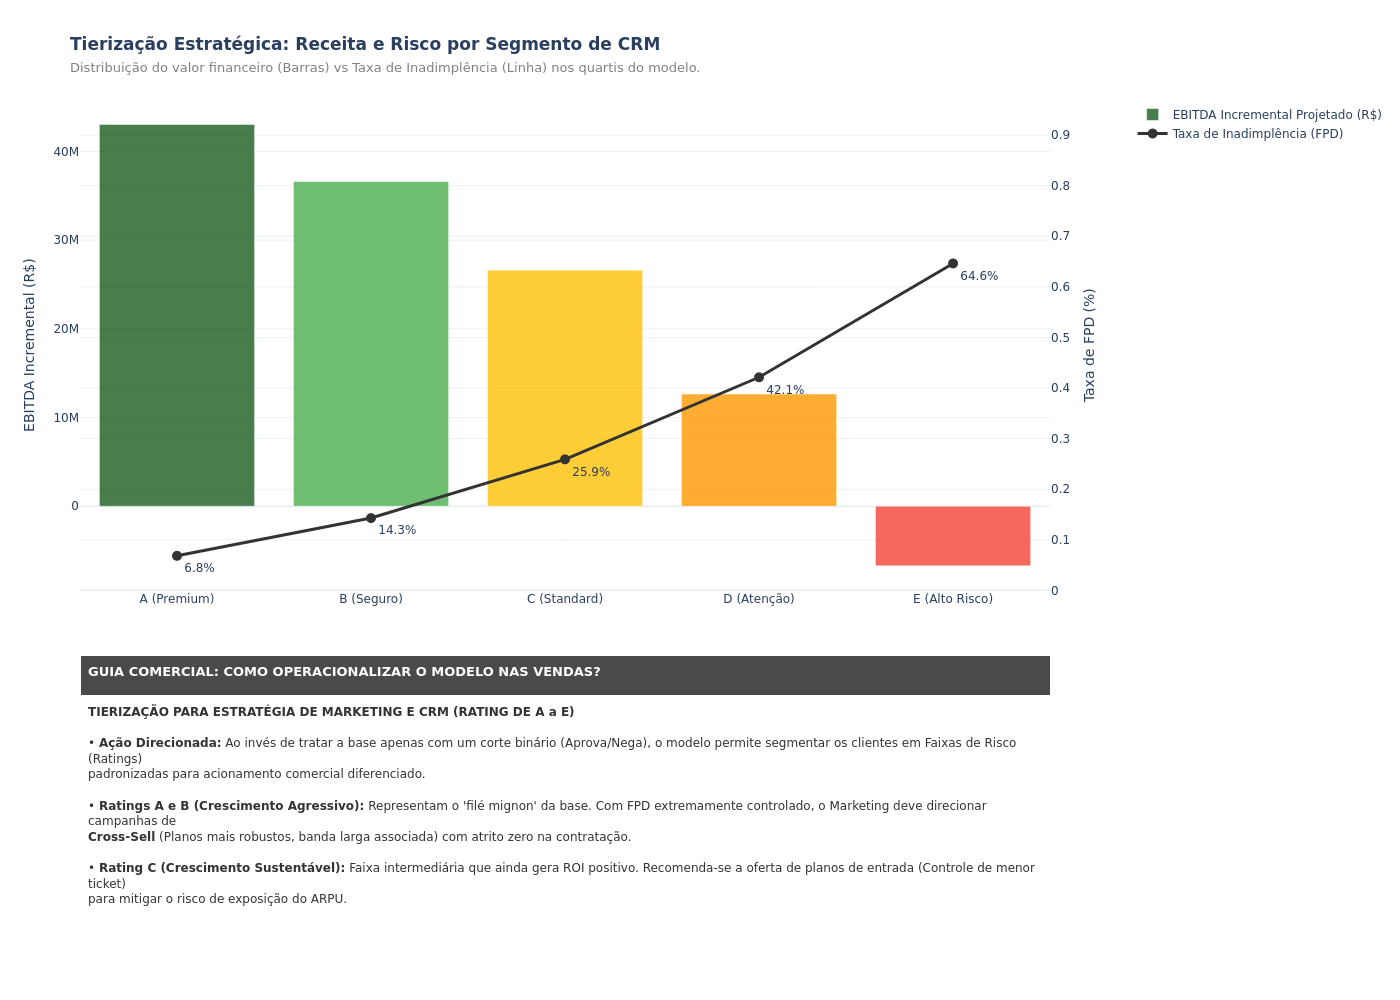

In [14]:
# ---------------------------------------------------------
# TIERIZAÇÃO DE RISCO: ESTRATÉGIA DE OFERTA POR RATING (A-E)
# ---------------------------------------------------------


print("⚙️ Gerando Tierização Estratégica para Ações de CRM...")

# Divide a base em 5 decis (Rating A até E) baseados na probabilidade do modelo
df_swap['rating_crm'] = pd.qcut(df_swap['prob_modelo'], q=5, labels=['A (Premium)', 'B (Seguro)', 'C (Standard)', 'D (Atenção)', 'E (Alto Risco)'])

analise_tier = df_swap.groupby('rating_crm').agg(
    Volume_CPFs=('prob_modelo', 'count'),
    Inadimplencia_FPD=('target', 'mean')
).reset_index()

# Escala os volumes e calcula a receita potencial por Tier
analise_tier['Vol_Nacional'] = analise_tier['Volume_CPFs'] * fator_escala * TAXA_CONVERSAO_META
analise_tier['EBITDA_Potencial'] = (analise_tier['Vol_Nacional'] * (1 - analise_tier['Inadimplencia_FPD']) * UPSELL * MESES_LTV) - \
                                   (analise_tier['Vol_Nacional'] * analise_tier['Inadimplencia_FPD'] * ARPU_CONTROLE * MESES_INADIMPLENCIA)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.08,
    row_heights=[0.65, 0.35],
    specs=[[{"secondary_y": True}], [{"type": "table"}]]
)

fig.add_trace(go.Bar(
    x=analise_tier['rating_crm'], y=analise_tier['EBITDA_Potencial'],
    name="EBITDA Incremental Projetado (R$)",
    marker_color=['#1B5E20', '#4CAF50', '#FFC107', '#FF9800', '#F44336'],
    opacity=0.8
), row=1, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=analise_tier['rating_crm'], y=analise_tier['Inadimplencia_FPD'],
    name="Taxa de Inadimplência (FPD)",
    mode="lines+markers+text",
    text=[f"{v:.1%}" for v in analise_tier['Inadimplencia_FPD']],
    textposition="bottom right",
    line=dict(color='#333333', width=3), marker=dict(size=10)
), row=1, col=1, secondary_y=True)

racional_tier = (
    "<b>TIERIZAÇÃO PARA ESTRATÉGIA DE MARKETING E CRM (RATING DE A a E)</b><br><br>"
    "• <b>Ação Direcionada:</b> Ao invés de tratar a base apenas com um corte binário (Aprova/Nega), o modelo permite segmentar os clientes "
    "em Faixas de Risco <br>(Ratings) padronizadas para acionamento comercial diferenciado.<br><br>"
    "• <b>Ratings A e B (Crescimento Agressivo):</b> Representam o 'filé mignon' da base. Com FPD extremamente controlado, o Marketing deve "
    "direcionar <br>campanhas de <b>Cross-Sell</b> (Planos mais robustos, banda larga associada) com atrito zero na contratação.<br><br>"
    "• <b>Rating C (Crescimento Sustentável):</b> Faixa intermediária que ainda gera ROI positivo. Recomenda-se a oferta de planos de "
    "entrada (Controle de menor <br>ticket) para mitigar o risco de exposição do ARPU.<br><br>"
    "• <b>Ratings D e E (Blindagem):</b> Concentram a vasta maioria do risco da base e destroem o EBITDA (Barras negativas). "
    "Estes clusters devem ser <br>compulsoriamente bloqueados de campanhas ativas de migração."
)

texto_formatado = wrap_paragraphs(racional_tier, width=170)
altura_celula = texto_formatado.count('<br>') * 26 + 50

fig.add_trace(go.Table(
    header=dict(
        values=["<b>GUIA COMERCIAL: COMO OPERACIONALIZAR O MODELO NAS VENDAS?</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Tierização Estratégica: Receita e Risco por Segmento de CRM</b><br><span style='font-size:13px;color:gray'>Distribuição do valor financeiro (Barras) vs Taxa de Inadimplência (Linha) nos quartis do modelo.</span>",
    height=1000, width=1400,
    template="plotly_white",
    hovermode="x unified",
    yaxis_title="EBITDA Incremental (R$)",
    yaxis2_title="Taxa de FPD (%)",
    yaxis2=dict(range=[0, analise_tier['Inadimplencia_FPD'].max() * 1.5]) # Ajuste para a linha não colar no topo
)

fig.write_image(FIGURES_DIR / '09_tierizacao_crm_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Gerando Análise de Sensibilidade: Elasticidade de Conversão de Vendas...


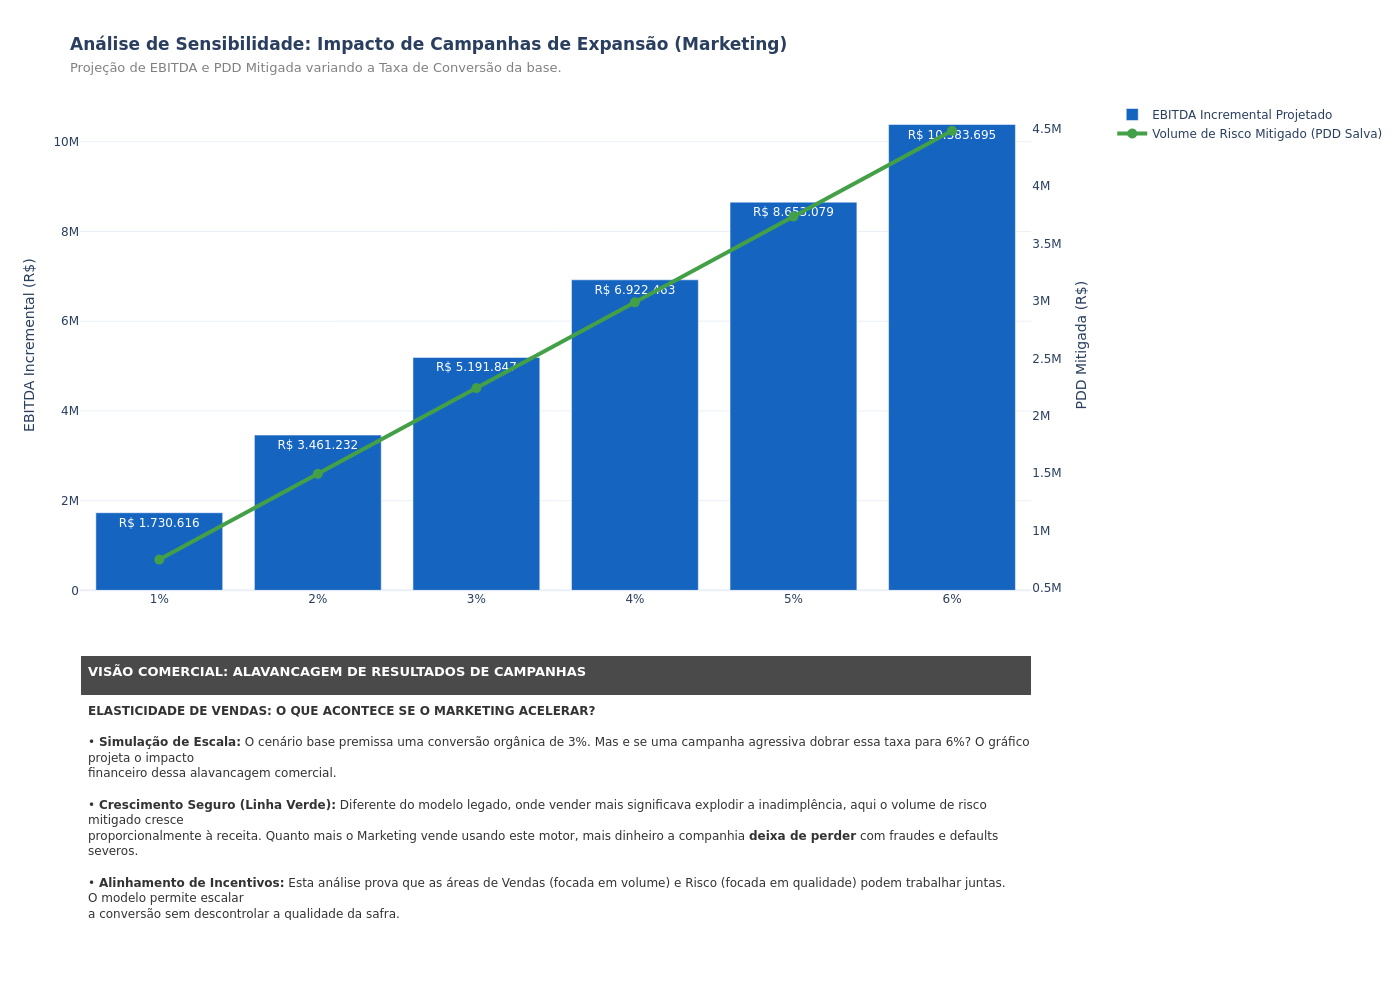

In [15]:
# ---------------------------------------------------------
# SENSIBILIDADE DE CONVERSÃO: IMPACTO DE CAMPANHAS DE MARKETING
# ---------------------------------------------------------


# Função exclusiva para blocos de texto HTML para evitar quebra do LaTeX no Plotly
def format_moeda_html(v):
    return f"R&#36; {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print("⚙️ Gerando Análise de Sensibilidade: Elasticidade de Conversão de Vendas...")

# Mantendo a política campeã fixa
taxa_aprov_num = float(taxa_campea.replace('%', '')) / 100
n_aprovados = int(len(df_swap) * taxa_aprov_num)

mask_mod = df_swap['rank_mod'] <= n_aprovados
mask_bur = df_swap['rank_bur'] <= n_aprovados
swap_in = (~mask_bur) & mask_mod
swap_out = mask_bur & (~mask_mod)

s_in_goods = swap_in.sum() - df_swap.loc[swap_in, 'target'].sum()
s_in_bads = df_swap.loc[swap_in, 'target'].sum()
s_out_goods = swap_out.sum() - df_swap.loc[swap_out, 'target'].sum()
s_out_bads = df_swap.loc[swap_out, 'target'].sum()

# Simulando o Marketing escalando as vendas de 1% até 6% da base elegível
cenarios_conversao = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06] 
resultados_mkt = []

for conv in cenarios_conversao:
    upsell_net = ((s_in_goods - s_out_goods) * fator_escala * conv * UPSELL * MESES_LTV)
    risco_net = ((s_out_bads - s_in_bads) * fator_escala * conv * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    ebitda_total = upsell_net + risco_net
    
    resultados_mkt.append({
        'Conversao': conv,
        'EBITDA_Total': ebitda_total,
        'Risco_Net': risco_net
    })

df_mkt = pd.DataFrame(resultados_mkt)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.08,
    row_heights=[0.65, 0.35],
    specs=[[{"secondary_y": True}], [{"type": "table"}]]
)

fig.add_trace(go.Bar(
    x=[f"{v*100:.0f}%" for v in df_mkt['Conversao']], 
    y=df_mkt['EBITDA_Total'],
    name="EBITDA Incremental Projetado",
    marker_color='#1565C0',
    text=[format_moeda_html(v) for v in df_mkt['EBITDA_Total']],
    textposition="auto"
), row=1, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=[f"{v*100:.0f}%" for v in df_mkt['Conversao']], 
    y=df_mkt['Risco_Net'],
    name="Volume de Risco Mitigado (PDD Salva)",
    mode="lines+markers",
    line=dict(color='#43A047', width=4), marker=dict(size=10)
), row=1, col=1, secondary_y=True)

racional_mkt = (
    "<b>ELASTICIDADE DE VENDAS: O QUE ACONTECE SE O MARKETING ACELERAR?</b><br><br>"
    "• <b>Simulação de Escala:</b> O cenário base premissa uma conversão orgânica de 3%. Mas e se uma campanha agressiva "
    "dobrar essa taxa para 6%? O gráfico <br>projeta o impacto financeiro dessa alavancagem comercial.<br><br>"
    "• <b>Crescimento Seguro (Linha Verde):</b> Diferente do modelo legado, onde vender mais significava explodir a inadimplência, "
    "aqui o volume de risco <br>mitigado cresce proporcionalmente à receita. Quanto mais o Marketing vende usando este motor, "
    "mais dinheiro a companhia <b>deixa de perder</b> com fraudes e defaults <br>severos.<br><br>"
    "• <b>Alinhamento de Incentivos:</b> Esta análise prova que as áreas de Vendas (focada em volume) e Risco (focada em qualidade) "
    "podem trabalhar juntas. <br>O modelo permite escalar a conversão sem descontrolar a qualidade da safra."
)

# Reutiliza a função wrap_paragraphs já declarada nas células anteriores
texto_formatado = wrap_paragraphs(racional_mkt, width=180)
altura_celula = texto_formatado.count('<br>') * 26 + 50

fig.add_trace(go.Table(
    header=dict(
        values=["<b>VISÃO COMERCIAL: ALAVANCAGEM DE RESULTADOS DE CAMPANHAS</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Análise de Sensibilidade: Impacto de Campanhas de Expansão (Marketing)</b><br><span style='font-size:13px;color:gray'>Projeção de EBITDA e PDD Mitigada variando a Taxa de Conversão da base.</span>",
    height=1000, width=1400,
    template="plotly_white",
    hovermode="x unified",
    yaxis_title="EBITDA Incremental (R$)",
    yaxis2_title="PDD Mitigada (R$)",
    yaxis2=dict(showgrid=False)
)

fig.write_image(FIGURES_DIR / '10_sensibilidade_conversao_v1.png', scale=2)
fig.show(renderer='png')